# 01 · Pantheon+SH0ES SNe

Eight cosmological scenarios over **Pantheon+SH0ES** (1701 SNe Ia with the full
STAT+SYS covariance), from the simplest (FlatLCDM 2D) to the most general
(w0waCDM 4D, with or without Cepheids).

### Shared pipeline

- Sampling: `build_chi2_dataset` with slices + random cloud, cached in `outputs/datasets/` (datasets persist between sessions).
- Training: `train_xgb(log_target=True)` (model caching disabled by default; retrain each session).
- XGBoost hyperparameters: `n_estimators=3000, learning_rate=0.03, max_depth=10`,
  `tree_method='hist'`, early stopping with `min_delta=1e-4` (auto for log targets).
- Contours: `res=100, sigma=2.0, theory_threshold=12`.
- SHAP values are in shifted-log10 chi2; a contribution of 0.5 ~ factor x3 in chi2.


## Index

| Sec. | Scenario                              | Dim | Cepheids (SH0ES) | Notes |
|------|---------------------------------------|-----|------------------|-------|
| [1.1](#1-1) | **FlatLCDM**                  | 2   | **NO** (M=-19.239 fixed, no mask) | Simplest baseline |
| [1.2](#1-2) | **Non-flat LambdaCDM** (Ode free) | 3 | **YES**         | Allows curvature Om_k = 1 - Om - Ode |
| [1.3](#1-3) | **FlatLCDM + free M**         | 3   | **YES**          | M absolute as a parameter (not marginalized) |
| [1.4](#1-4) | **FlatLCDM + SALT2 alpha/beta** | 4 | **YES**          | Stretch (alpha) and color (beta) free |
| [1.5](#1-5) | **wCDM**                      | 3   | **YES**          | Constant dark energy equation of state |
| [1.6](#1-6) | **w0waCDM with SH0ES**        | 4   | **YES**          | CPL: w(z) = w0 + wa*z/(1+z) with Cepheids |
| [1.7](#1-7) | **w0waCDM without SH0ES**     | 4   | **NO** (standard z>0.01 mask) | Same model, no Cepheid anchor |
| [1.8](#1-8) | **w0waCDM with z>0.25**       | 4   | **NO** (aggressive cut, no calibrators) | Remove local flow and Cepheids |

### About Cepheids (SH0ES)

Pantheon+ includes a subset of SNe Ia in galaxies with direct Cepheid distance
measurements (SH0ES calibrators). When `use_cepheid_calibrators=True`, those
SNe do NOT follow the cosmological model: their distance modulus is fixed to
`CEPH_DIST`. The rest do follow it. This anchors the luminosity scale and thus
H0, which is otherwise degenerate with M.


## <a id="setup"></a>Setup (run first)


In [62]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_pantheon_plus
from cosmoml.theory.sne import chi2_sne

from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_contour_2d, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.config import OUTPUTS_DIR

use_paper_style()

NB_NAME = "01_SN_Panth+"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Set to True to retrain models (ignore cache)
FORCE_RETRAIN = False

print(f"Datasets:  {DATASETS_DIR}/{{SECTION}}_dataset.csv")
print(f"Models:    {MODELS_DIR}/{{SECTION}}_model.ubj  (FORCE_RETRAIN={FORCE_RETRAIN})")
print(f"Figures:   {FIGURES_DIR}/{{SECTION}}_*.png")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Datasets:  /home/aleja/PhysicsML/CosmoML/outputs/datasets/{SECTION}_dataset.csv
Models:    /home/aleja/PhysicsML/CosmoML/outputs/models/{SECTION}_model.ubj  (FORCE_RETRAIN=False)
Figures:   /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/{SECTION}_*.png


## <a id="1-1"></a>1.1 FlatLCDM — 2D (Om, H0), no Cepheids

**Model:** `FlatLambdaCDM` (Om, H0), absolute magnitude M fixed at the fiducial.
**Data:** Pantheon+SH0ES, no mask — all 1701 SNe follow the cosmological model.
**Cepheids:** **NO** (`use_cepheid_calibrators=False`, `apply_mask=False`).
M = -19.23904 (calibrated for Om=0.334, H0=73.6).

Simplest baseline: no Cepheid treatment, no zHEL/zHD correction.


In [22]:
SECTION = "1_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0"]
M_CALIBRATED = -19.23904

sne = load_pantheon_plus(apply_mask=False)
print(f"Pantheon+ (no mask): {len(sne)} SNe")

def chi2_fn(Om, H0):
    return chi2_sne(
        sne, model="FlatLambdaCDM",
        Om=Om, H0=H0,
        M=M_CALIBRATED,
        use_cepheid_calibrators=False,
        use_zhel_correction=False,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.334, 73.6])))
_m.limits = [(0.1, 0.5), (65, 80)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (no mask): 1701 SNe
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3612  H0=73.3094
chi2(best-fit) = 1752.51


In [23]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[dict(Om=(REF['Om']-0.10, REF['Om']+0.10),
                     H0=(REF['H0']-2.5, REF['H0']+2.5), _n=10_000)],
        anchor=REF, n_anchor=2000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_1_dataset.csv
min chi2 = 1752.508


  loading cached model: 1_1_model.ubj


  R2=0.99934 | best_iter=536 | n_train=8,500 | n_val=1,501
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_learning_curve.png


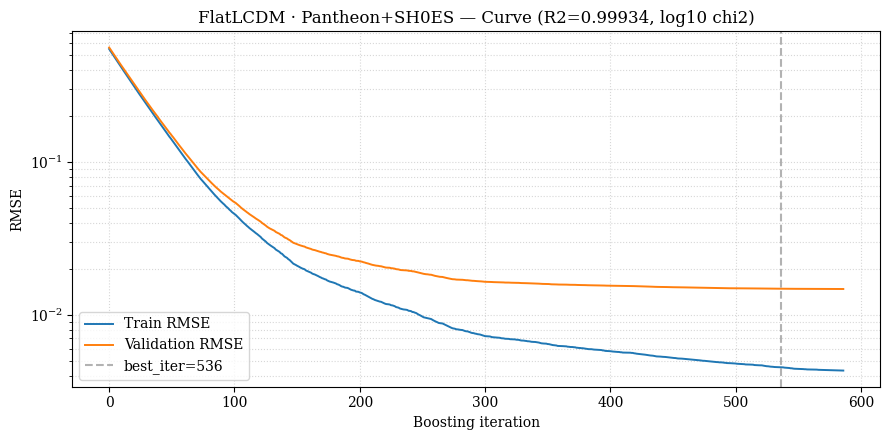

In [24]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"FlatLCDM · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_Om_H0.png


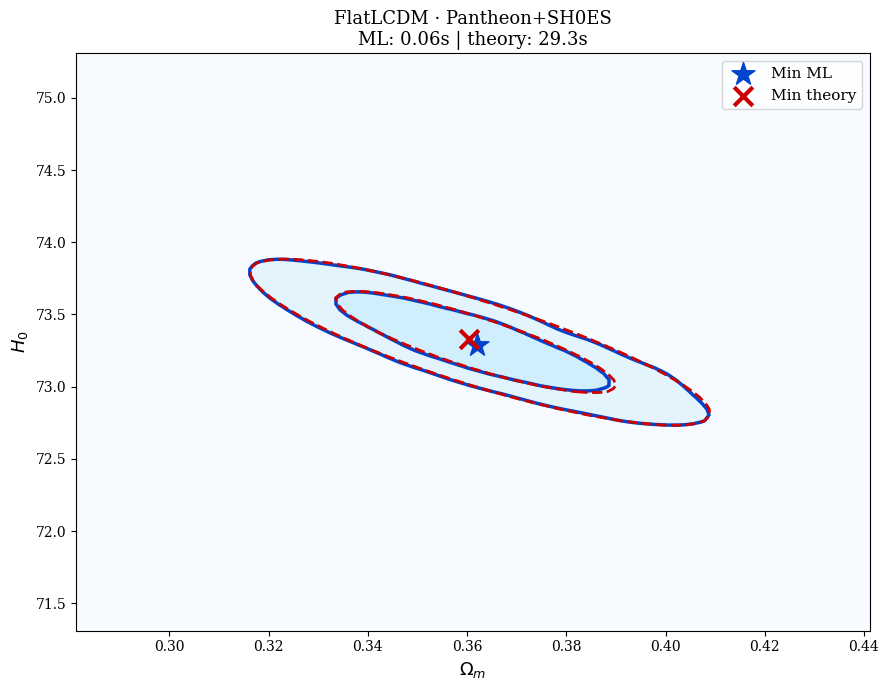

{'Z_ml': array([[2299.3083, 2296.74  , 2292.1274, ..., 1862.7007, 1861.3298,
         1860.6062],
        [2293.426 , 2290.8928, 2286.3315, ..., 1860.1505, 1858.8105,
         1858.1   ],
        [2282.866 , 2280.3813, 2275.894 , ..., 1855.6925, 1854.4314,
         1853.759 ],
        ...,
        [1844.0276, 1844.5533, 1845.517 , ..., 2238.0337, 2243.1743,
         2246.1033],
        [1847.1559, 1847.7328, 1848.7856, ..., 2247.626 , 2252.4119,
         2255.109 ],
        [1848.845 , 1849.4496, 1850.5514, ..., 2252.9783, 2257.5415,
         2260.0938]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.05926704406738281,
 'time_th': 29.278459072113037}

In [25]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="H0",
    x_range=(REF['Om']-0.08, REF['Om']+0.08),
    y_range=(REF['H0']-2.0, REF['H0']+2.0),
    fixed={},
    theory_fn=chi2_fn,
    title=r"FlatLCDM · Pantheon+SH0ES",
    x_label=r"$\Omega_m$", y_label=r"$H_0$",
    save_path=None,
    show=True, **common,
    global_min_chi2=res_opt.fun,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_beeswarm.png


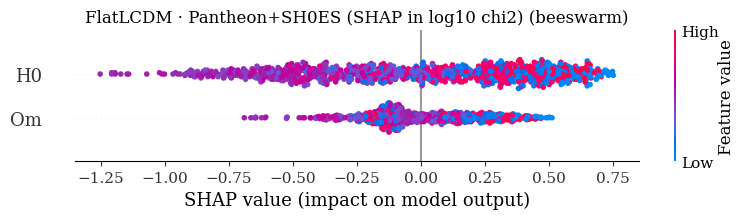

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_bar.png


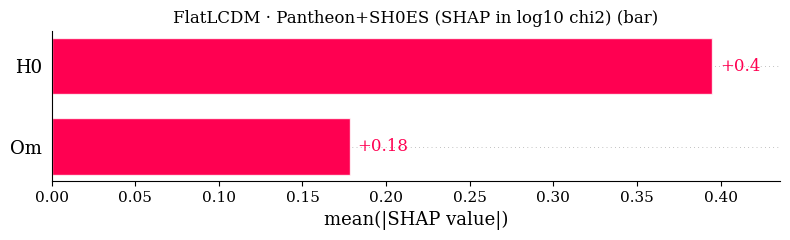

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_waterfall.png


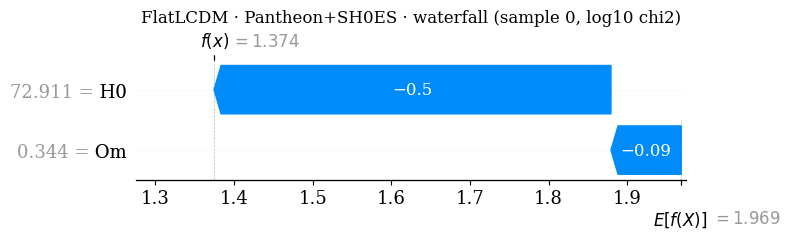

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_Om.png


<Figure size 640x480 with 0 Axes>

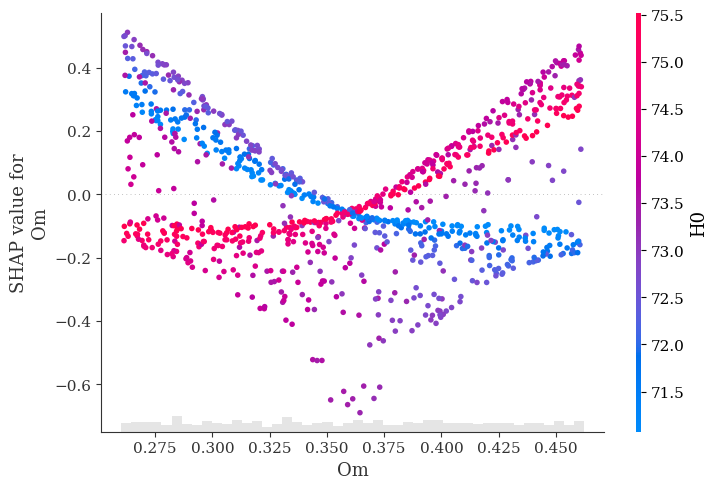

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_H0.png


<Figure size 640x480 with 0 Axes>

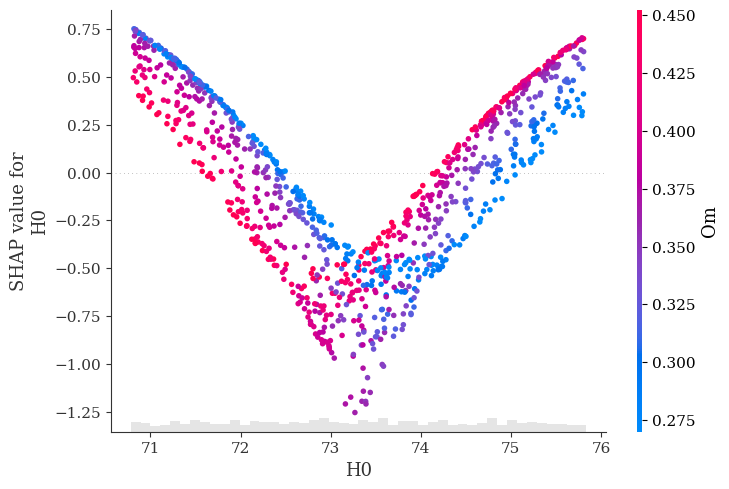

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_1_shap_H0.png')]

In [26]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="FlatLCDM · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="FlatLCDM · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)


## <a id="1-2"></a>1.2 Non-flat LambdaCDM — 3D (Om, Ode, H0) with Cepheids

**Model:** `LambdaCDM` (Om, Ode, H0); curvature Om_k = 1 - Om - Ode is free.
**Data:** Pantheon+SH0ES with the standard mask `(zHD>0.01) | IS_CALIBRATOR`.
**Cepheids:** **YES** — calibrators anchor H0 via `mu = CEPH_DIST`.

Tests flatness: the Om-Ode contour should lie close to the Om + Ode = 1 line if
the universe is spatially flat.


In [27]:
SECTION = "1_2"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "Ode", "H0"]

sne = load_pantheon_plus(apply_mask=True)
print(f"Pantheon+ (mask z>0.01 OR calibrators): {len(sne)} SNe, calibradores={sne.is_calib.sum()}")

def chi2_fn(Om, Ode, H0):
    return chi2_sne(
        sne, model="LambdaCDM",
        Om=Om, Ode=Ode, H0=H0,
        M="marginalize",
        use_cepheid_calibrators=True,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3, 0.7, 73.04])))
_m.limits = [(0.1, 0.5), (0.4, 1.0), (65, 80)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  Ode={REF['Ode']:.4f}  H0={REF['H0']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (mask z>0.01 OR calibrators): 1657 SNe, calibradores=77
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3036  Ode=0.6251  H0=73.4603
chi2(best-fit) = 1451.70


In [28]:
def builder():
    N = 7_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(Om=(0.0, 0.8), Ode=(0.0, 1.2), H0=REF['H0'],          _n=N),
            dict(Om=(0.0, 0.8), H0=(20, 100),   Ode=REF['Ode'],        _n=N),
            dict(H0=(20, 100),  Ode=(0.0, 1.2), Om=REF['Om'],          _n=N),
        ],
        random_box=dict(Om=(0.0, 1.0), Ode=(0.0, 1.5), H0=(20, 100)),
        n_random=20_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_2_dataset.csv
min chi2 = 1451.722


  loading cached model: 1_2_model.ubj
  R2=0.99952 | best_iter=717 | n_train=34,430 | n_val=6,077
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_learning_curve.png


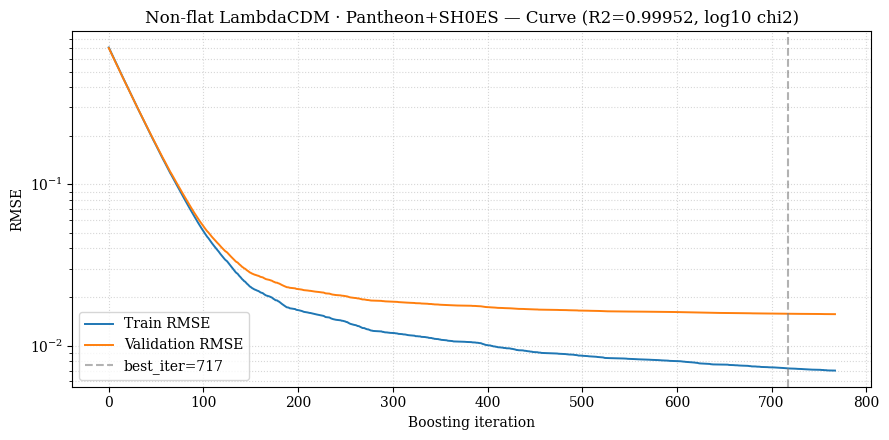

In [29]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"Non-flat LambdaCDM · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $\Omega_\Lambda$ vs $\Omega_m$  ({'H0': 73.46034923581617}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_Om_Ode.png


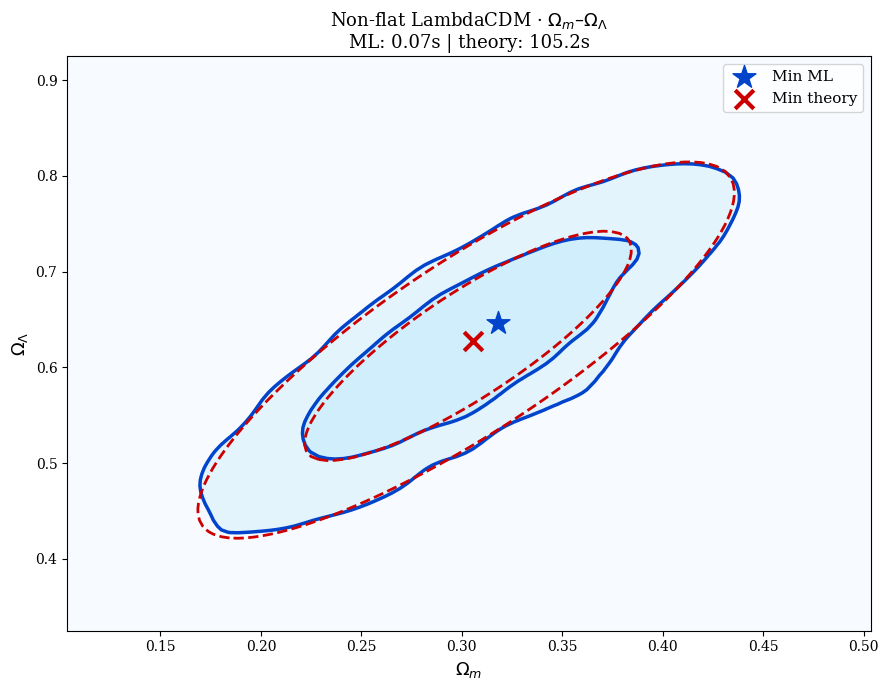

--- $H_0$ vs $\Omega_m$  ({'Ode': 0.6250539821887453}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_Om_H0.png


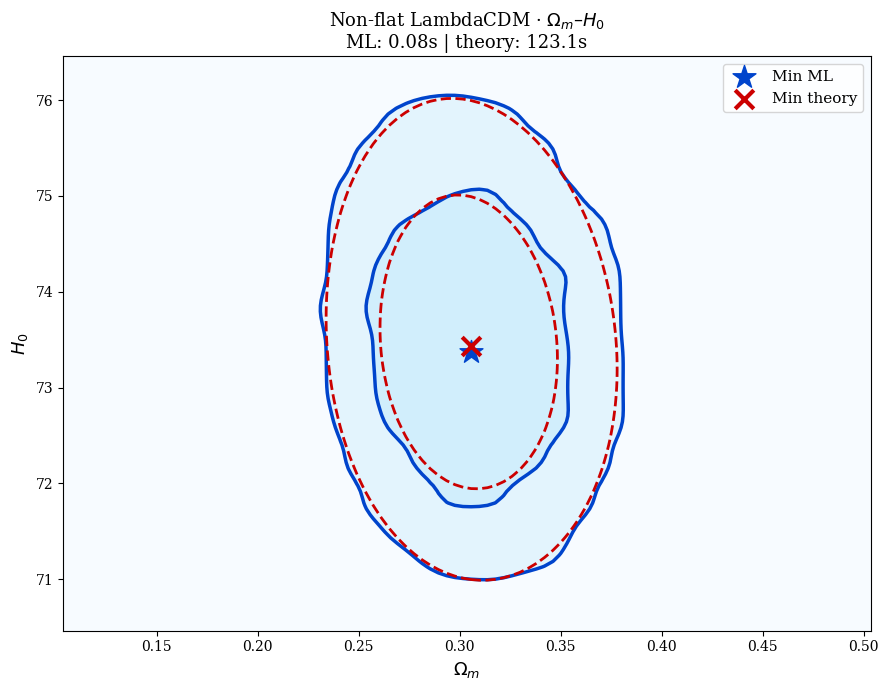

--- $H_0$ vs $\Omega_\Lambda$  ({'Om': 0.30359726739199294}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_Ode_H0.png


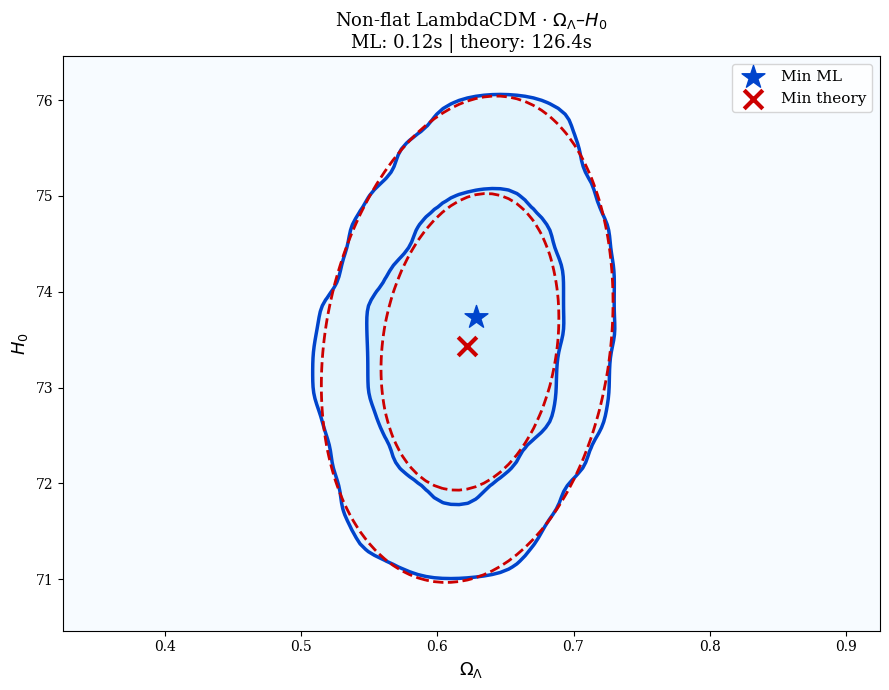

In [30]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.20, REF['Om']+0.20),
    Ode=(REF['Ode']-0.30, REF['Ode']+0.30),
    H0=(REF['H0']-3.0, REF['H0']+3.0),
)
LABELS = dict(Om=r"$\Omega_m$", Ode=r"$\Omega_\Lambda$", H0=r"$H_0$")

for x, y in [('Om','Ode'), ('Om','H0'), ('Ode','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"Non-flat LambdaCDM · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_beeswarm.png


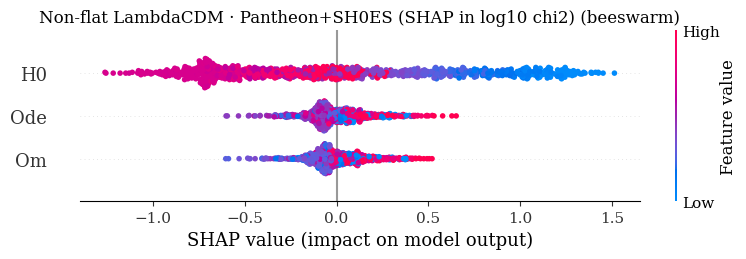

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_bar.png


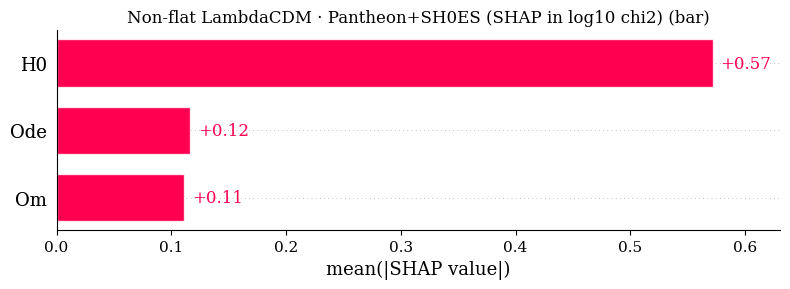

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_waterfall.png


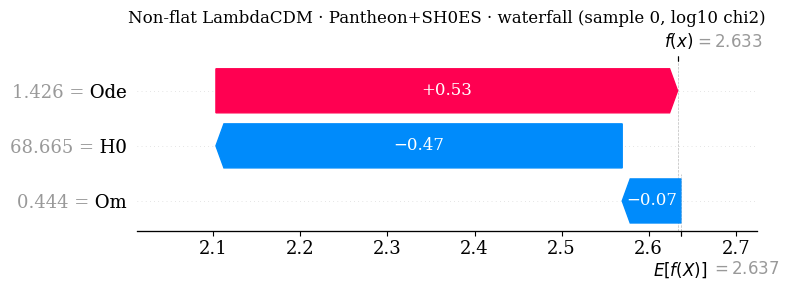

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_Om.png


<Figure size 640x480 with 0 Axes>

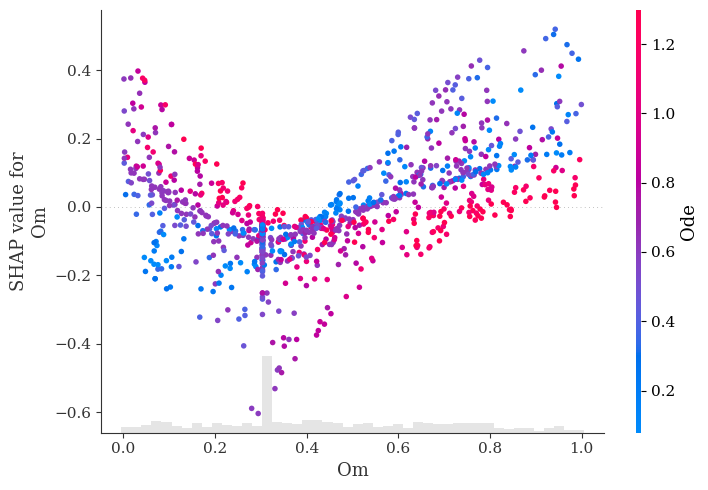

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_Ode.png


<Figure size 640x480 with 0 Axes>

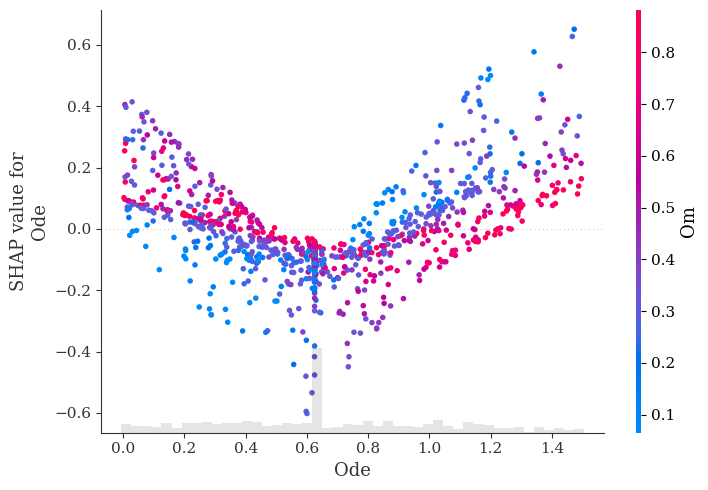

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_H0.png


<Figure size 640x480 with 0 Axes>

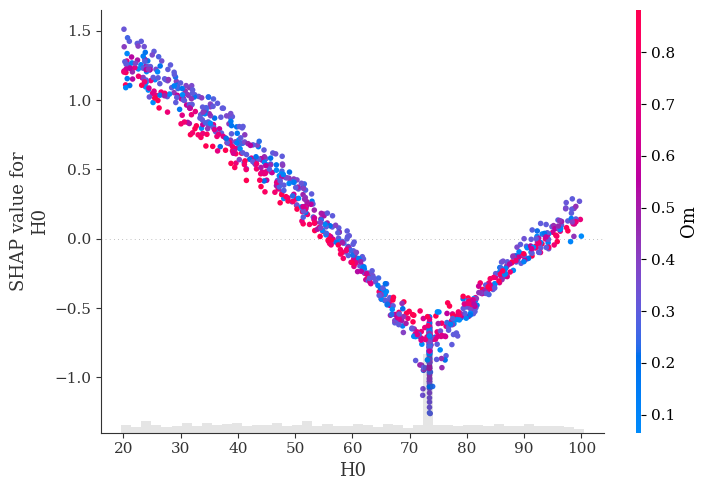

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_Ode.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_shap_H0.png')]

In [31]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="Non-flat LambdaCDM · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="Non-flat LambdaCDM · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)


--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=3) ---
  loading CPU booster copy...
  step   200/5000  |  95 it/s  |  ETA 51s  |  acc 0.50  |  diagonal
  step   400/5000  |  105 it/s  |  ETA 44s  |  acc 0.41  |  multivar
  step   600/5000  |  108 it/s  |  ETA ≤0s  |  acc 0.38  |  τ=24.5  ESS=4178/5000  |  multivar
  step   800/5000  |  107 it/s  |  ETA ≤0s  |  acc 0.36  |  τ=35.0  ESS=5859/5000  |  multivar
  done: 7.5s  |  106 it/s  |  acceptance 0.363  |  multivariate proposal
  flat chain: 205,312 samples (512 chains × 401 steps)  |  τ_max=35.0  |  ESS=5874
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_2_corner.png


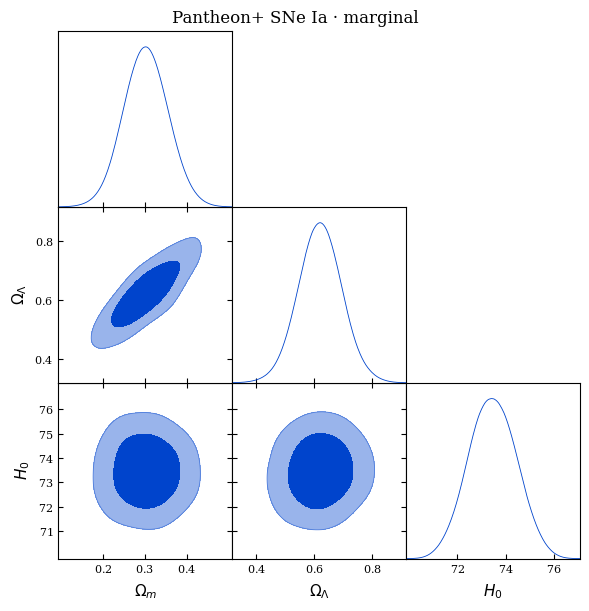

array([[ 0.31452438,  0.63774943, 72.77649689],
       [ 0.27219278,  0.62097967, 73.92184448],
       [ 0.28768474,  0.63303256, 72.33613586],
       ...,
       [ 0.29693964,  0.54719716, 72.19945526],
       [ 0.34676769,  0.62464982, 74.31545258],
       [ 0.21242347,  0.49248922, 72.08808136]], shape=(205312, 3))

In [32]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="Pantheon+ SNe Ia · marginal",
    save_path=None,
    show=True,
)

## <a id="1-3"></a>1.3 FlatLCDM + free M — 3D (Om, H0, M) with Cepheids

**Model:** `FlatLambdaCDM` (Om, H0) with absolute magnitude M as a **free parameter**
(NOT marginalized).
**Data:** Pantheon+SH0ES with the standard mask.
**Cepheids:** **YES**.

Useful for visualizing the M–H0 degeneracy explicitly instead of marginalizing it out.


In [33]:
SECTION = "1_3"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "M"]

sne = load_pantheon_plus(apply_mask=True)
print(f"Pantheon+ (masked): {len(sne)} SNe")

def chi2_fn(Om, H0, M):
    return chi2_sne(
        sne, model="FlatLambdaCDM",
        Om=Om, H0=H0,
        M=M,
        use_cepheid_calibrators=True,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.334, 73.04, -19.25])))
_m.limits = [(0.1, 0.5), (65, 80), (-19.4, -19.1)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  M={REF['M']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (masked): 1657 SNe
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3317  H0=73.5325  M=-19.2441
chi2(best-fit) = 1452.02


In [34]:
def builder():
    N = 4_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(H0=(65, 80),  M=(-19.35, -19.15), Om=REF['Om'],   _n=N),
            dict(Om=(0.1, 0.5), M=(-19.35, -19.15), H0=REF['H0'],  _n=N),
            dict(Om=(0.1, 0.5), H0=(65, 80),       M=REF['M'],     _n=N),
            dict(Om=(0.2, 0.45), H0=(66, 78),     M=(-19.30, -19.20), _n=N),
        ],
        random_box=dict(Om=(0.1, 0.6), H0=(60, 85), M=(-19.40, -19.10)),
        n_random=15_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_3_dataset.csv
min chi2 = 1452.035


  loading cached model: 1_3_model.ubj
  R2=0.99675 | best_iter=1266 | n_train=26,350 | n_val=4,650
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_learning_curve.png


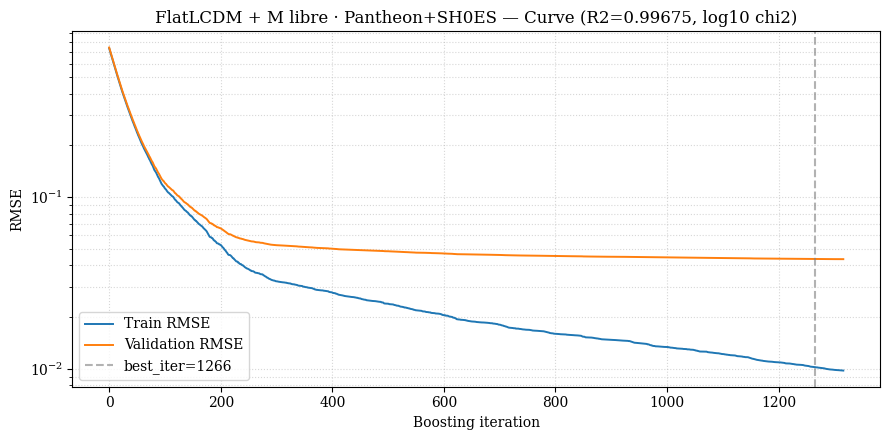

In [35]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"FlatLCDM + M libre · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'M': -19.244089439867864}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_Om_H0.png


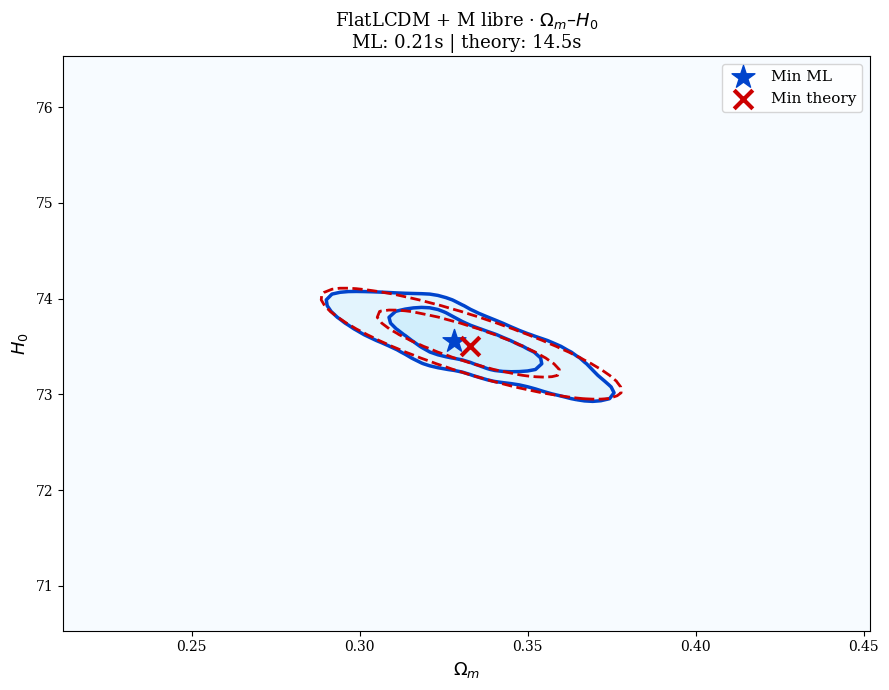

--- $M$ vs $\Omega_m$  ({'H0': 73.53246993819143}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_Om_M.png


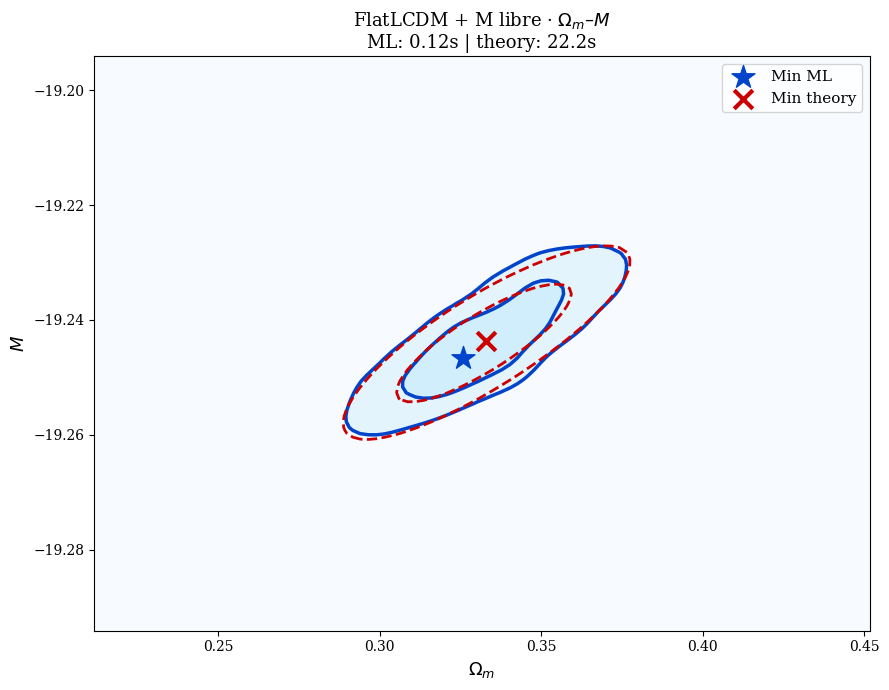

--- $M$ vs $H_0$  ({'Om': 0.33174608165187713}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_H0_M.png


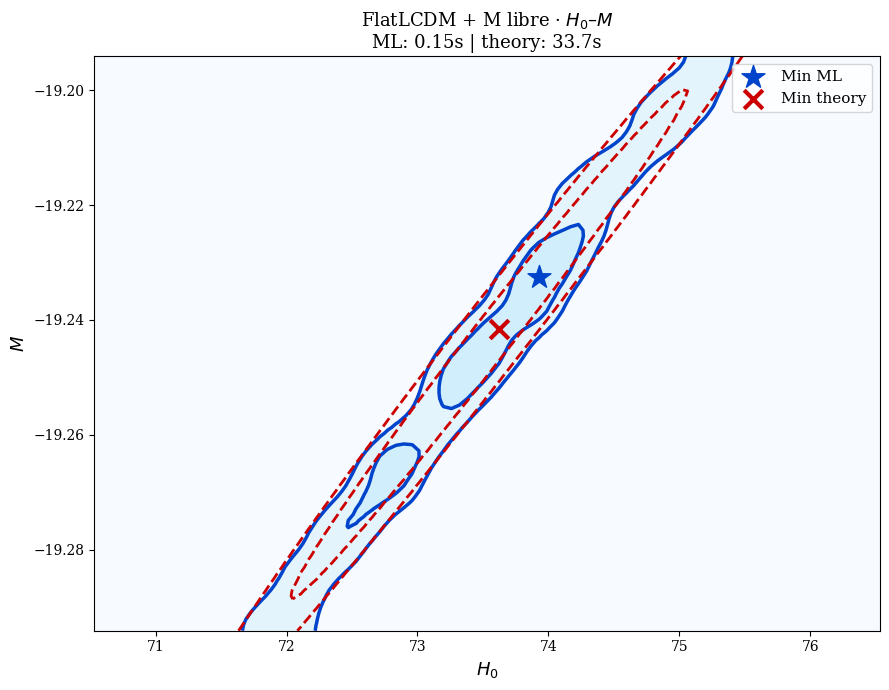

In [36]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.12, REF['Om']+0.12),
    H0=(REF['H0']-3.0, REF['H0']+3.0),
    M=(REF['M']-0.05, REF['M']+0.05),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", M=r"$M$")

for x, y in [('Om','H0'), ('Om','M'), ('H0','M')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"FlatLCDM + M libre · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_beeswarm.png


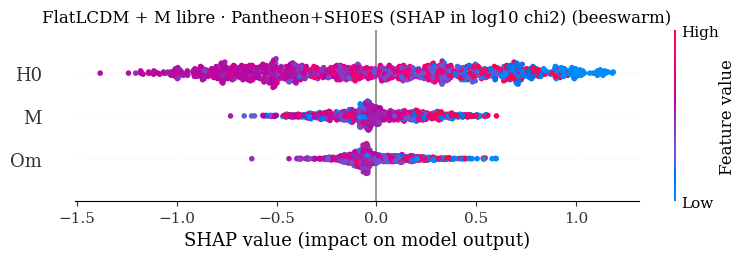

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_bar.png


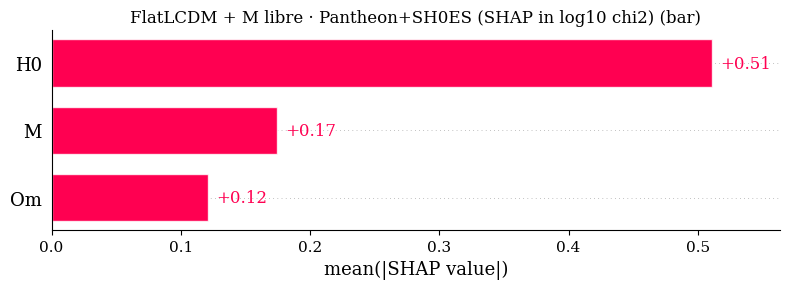

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_waterfall.png


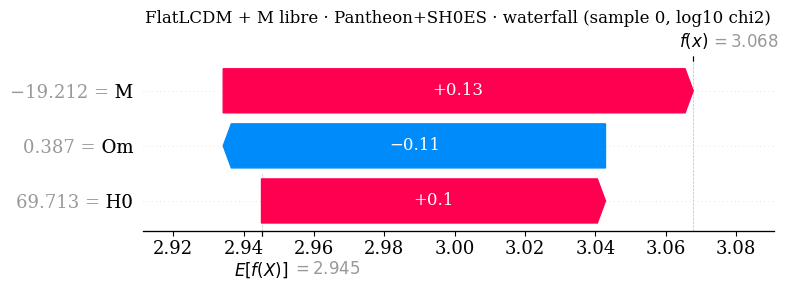

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_Om.png


<Figure size 640x480 with 0 Axes>

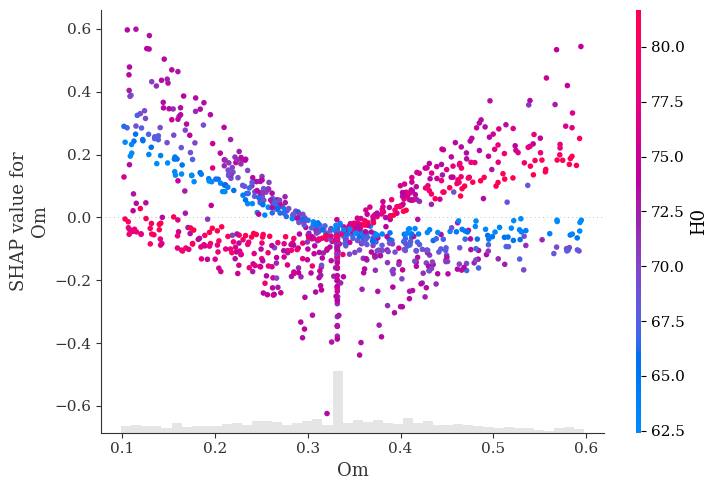

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_H0.png


<Figure size 640x480 with 0 Axes>

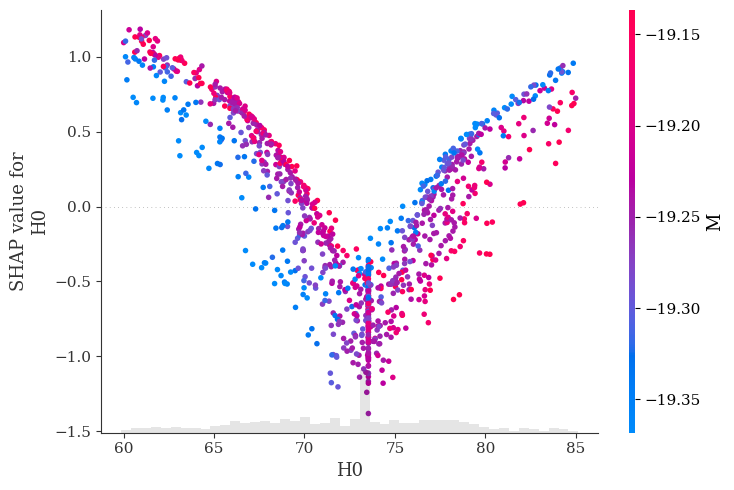

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_M.png


<Figure size 640x480 with 0 Axes>

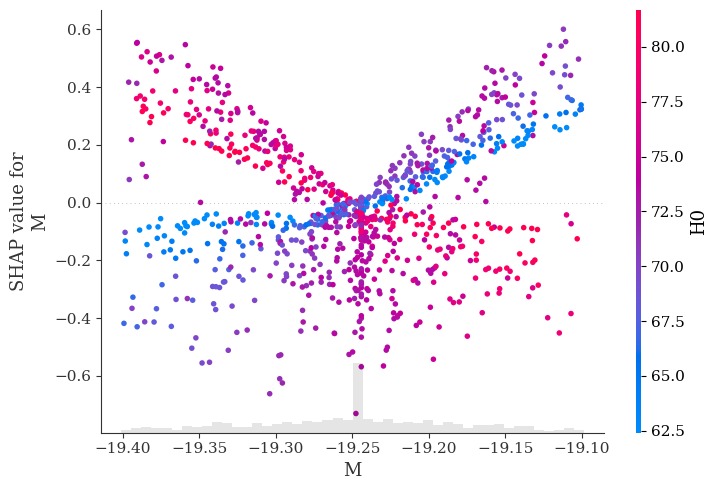

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_shap_M.png')]

In [37]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="FlatLCDM + M libre · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="FlatLCDM + M libre · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)


--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=3) ---
  loading CPU booster copy...
  step   200/5000  |  76 it/s  |  ETA 63s  |  acc 0.36  |  diagonal
  step   400/5000  |  79 it/s  |  ETA 59s  |  acc 0.36  |  multivar
  step   600/5000  |  79 it/s  |  ETA ≤2s  |  acc 0.32  |  τ=33.3  ESS=3071/5000  |  multivar
  step   800/5000  |  57 it/s  |  ETA ≤0s  |  acc 0.30  |  τ=36.5  ESS=5609/5000  |  multivar
  done: 14.0s  |  57 it/s  |  acceptance 0.298  |  multivariate proposal
  flat chain: 205,312 samples (512 chains × 401 steps)  |  τ_max=36.5  |  ESS=5623
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_3_corner.png


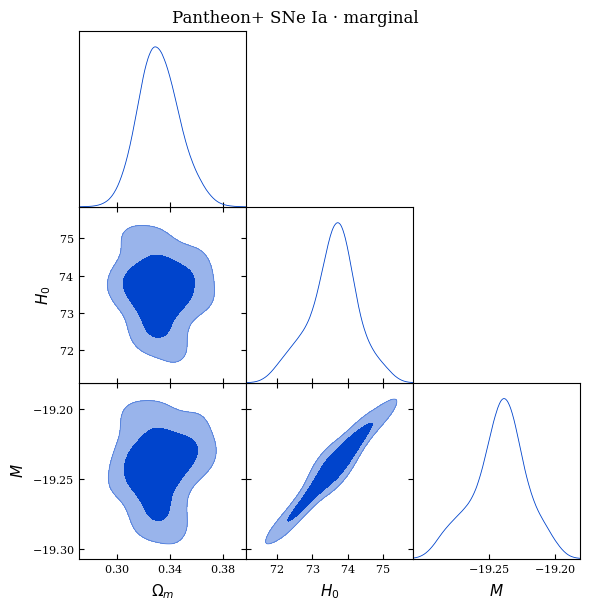

array([[  0.32159027,  73.8156662 , -19.23141479],
       [  0.32180992,  73.57250977, -19.23963165],
       [  0.33614549,  73.69682312, -19.23666573],
       ...,
       [  0.33870751,  73.60381317, -19.24560928],
       [  0.33565173,  73.51051331, -19.24098206],
       [  0.32856223,  73.48014069, -19.24502373]], shape=(205312, 3))

In [38]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="Pantheon+ SNe Ia · marginal",
    save_path=None,
    show=True,
)

## <a id="1-4"></a>1.4 FlatLCDM + SALT2 alpha/beta — 4D (Om, H0, alpha, beta)

**Model:** `FlatLambdaCDM` (Om, H0) with the SALT2 correction applied to m_b:
`m_b_corr += (alpha - alpha0)*x1 - (beta - beta0)*c`.
**Data:** Pantheon+SH0ES with the standard mask, x1/c loaded.
**Cepheids:** **YES**.

alpha (stretch) and beta (color) are SALT2 standardization parameters. The
Pantheon+ paper fiducials are alpha0=0.14, beta0=3.1.


In [39]:
SECTION = "1_4"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "alpha", "beta"]

# Need x1, c -> include_x1c=True
sne = load_pantheon_plus(apply_mask=True, include_x1c=True)
print(f"Pantheon+ (masked, with x1/c): {len(sne)} SNe")

def chi2_fn(Om, H0, alpha, beta):
    return chi2_sne(
        sne, model="FlatLambdaCDM",
        Om=Om, H0=H0,
        M="marginalize",
        alpha=alpha, beta=beta,
        use_cepheid_calibrators=True,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.334, 73.04, 0.14, 3.1])))
_m.limits = [(0.1, 0.5), (65, 80), (0.05, 0.25), (2.0, 4.5)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  alpha={REF['alpha']:.4f}  beta={REF['beta']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (masked, with x1/c): 1657 SNe
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3326  H0=73.5431  alpha=0.1437  beta=3.0163
chi2(best-fit) = 1449.73


In [40]:
def builder():
    N = 8_000
    rng_alpha, rng_beta = (0.05, 0.25), (2.0, 4.5)
    rng_om, rng_h0 = (0.20, 0.45), (70, 76)
    pares = [("Om","H0"), ("Om","alpha"), ("Om","beta"),
             ("H0","alpha"), ("H0","beta"), ("alpha","beta")]
    rangos = dict(Om=rng_om, H0=rng_h0, alpha=rng_alpha, beta=rng_beta)
    slices = [{**REF, a: rangos[a], b: rangos[b], "_n": N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices,
        random_box=dict(Om=rng_om, H0=rng_h0, alpha=rng_alpha, beta=rng_beta),
        n_random=30_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_4_dataset.csv
min chi2 = 1449.732


  loading cached model: 1_4_model.ubj
  R2=0.99969 | best_iter=399 | n_train=66,300 | n_val=11,700
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_learning_curve.png


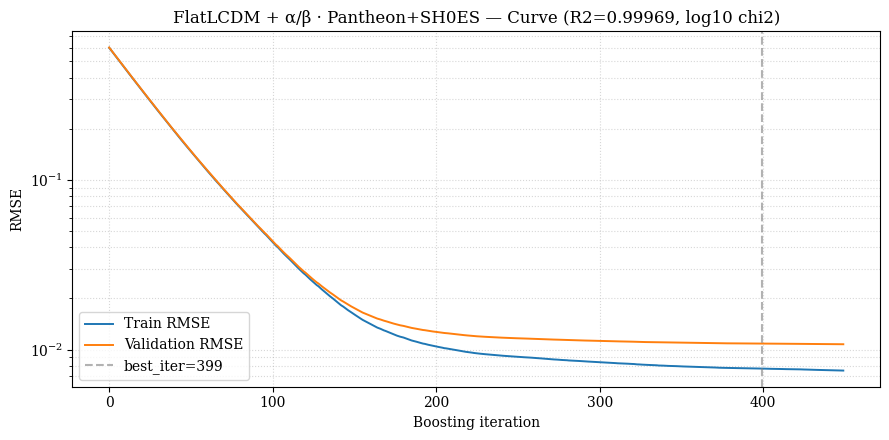

In [41]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"FlatLCDM + α/β · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'alpha': 0.14369751011117948, 'beta': 3.0162511471632416}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_Om_H0.png


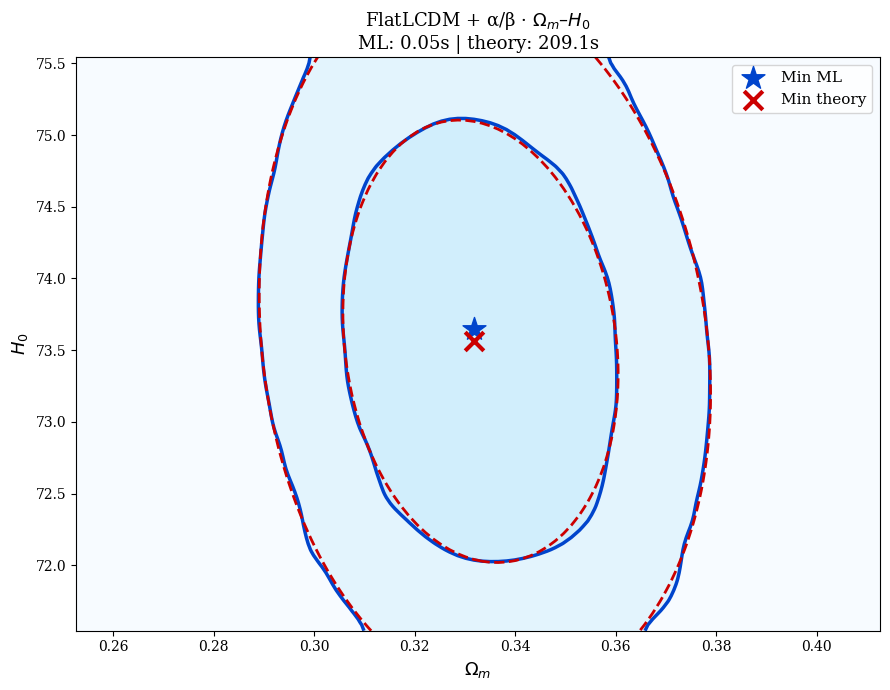

--- $\alpha$ vs $\Omega_m$  ({'H0': 73.54312976586354, 'beta': 3.0162511471632416}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_Om_alpha.png


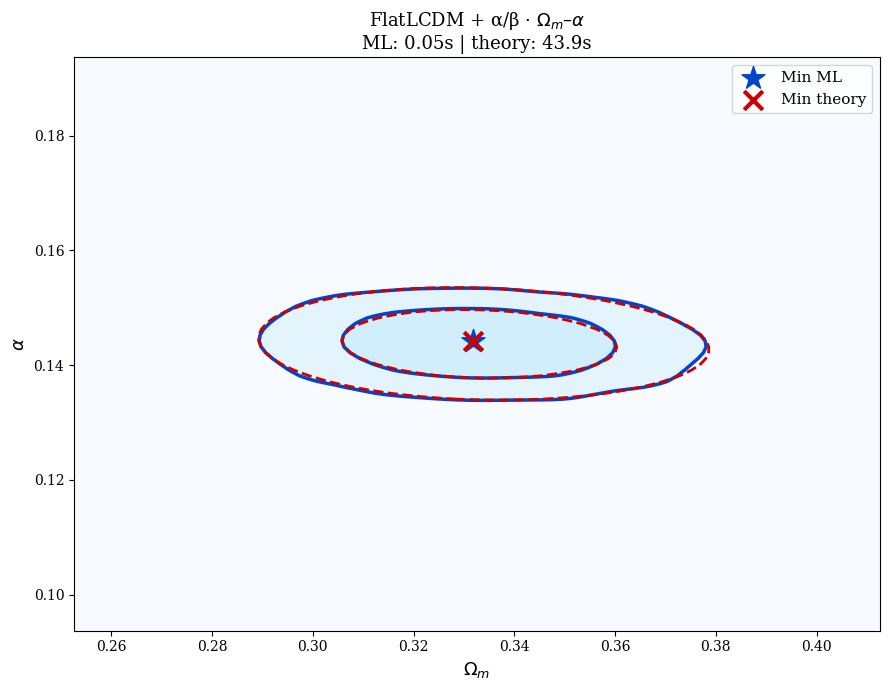

--- $\beta$ vs $\Omega_m$  ({'H0': 73.54312976586354, 'alpha': 0.14369751011117948}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_Om_beta.png


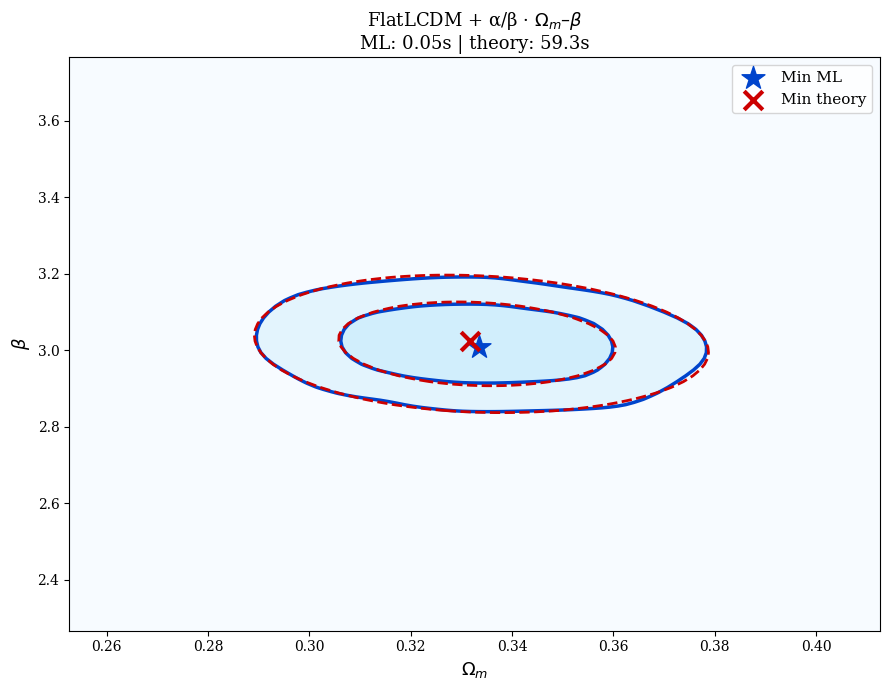

--- $\alpha$ vs $H_0$  ({'Om': 0.332602481238481, 'beta': 3.0162511471632416}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_H0_alpha.png


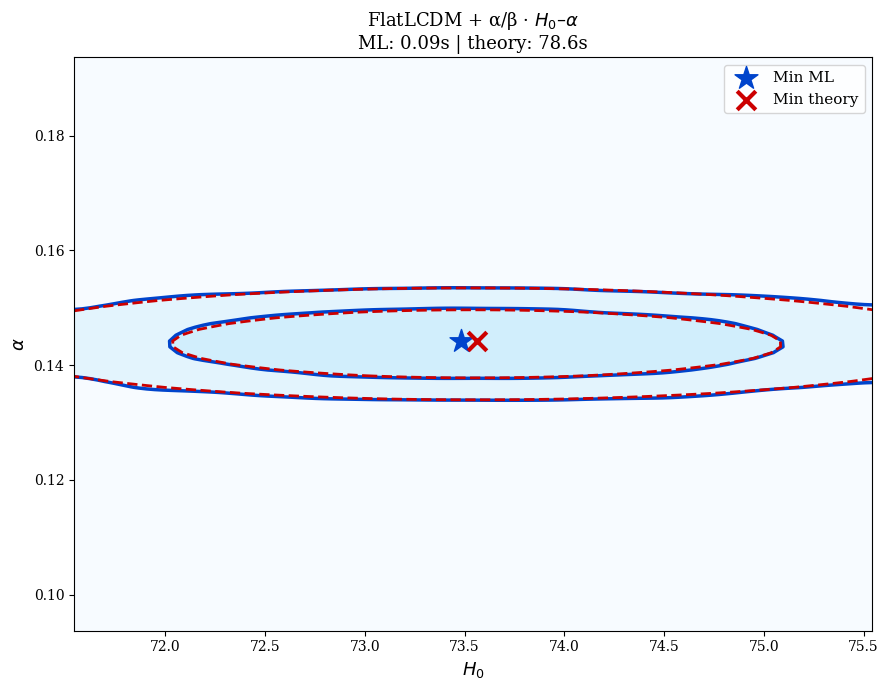

--- $\beta$ vs $H_0$  ({'Om': 0.332602481238481, 'alpha': 0.14369751011117948}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_H0_beta.png


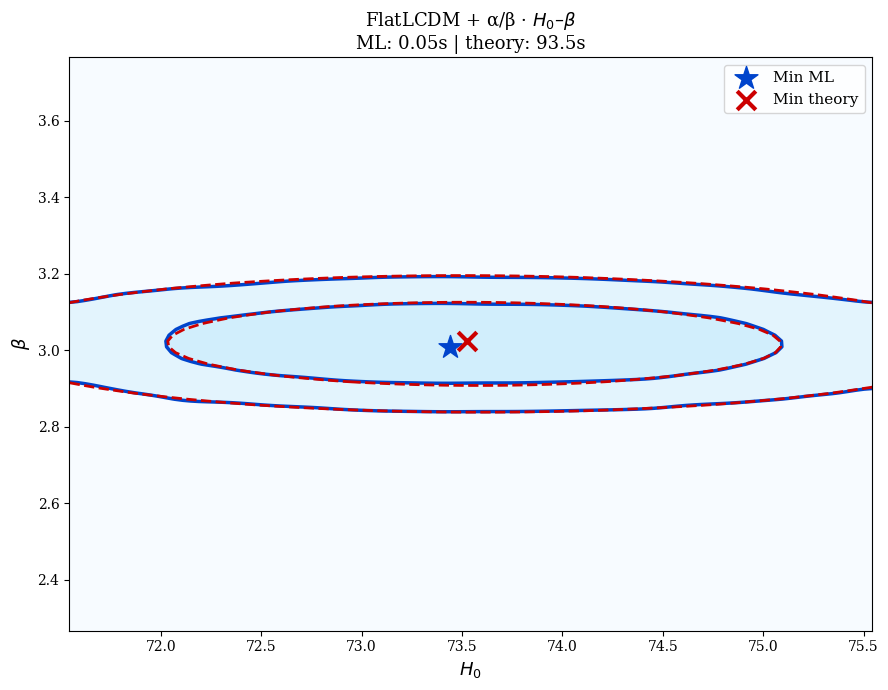

--- $\beta$ vs $\alpha$  ({'Om': 0.332602481238481, 'H0': 73.54312976586354}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_alpha_beta.png


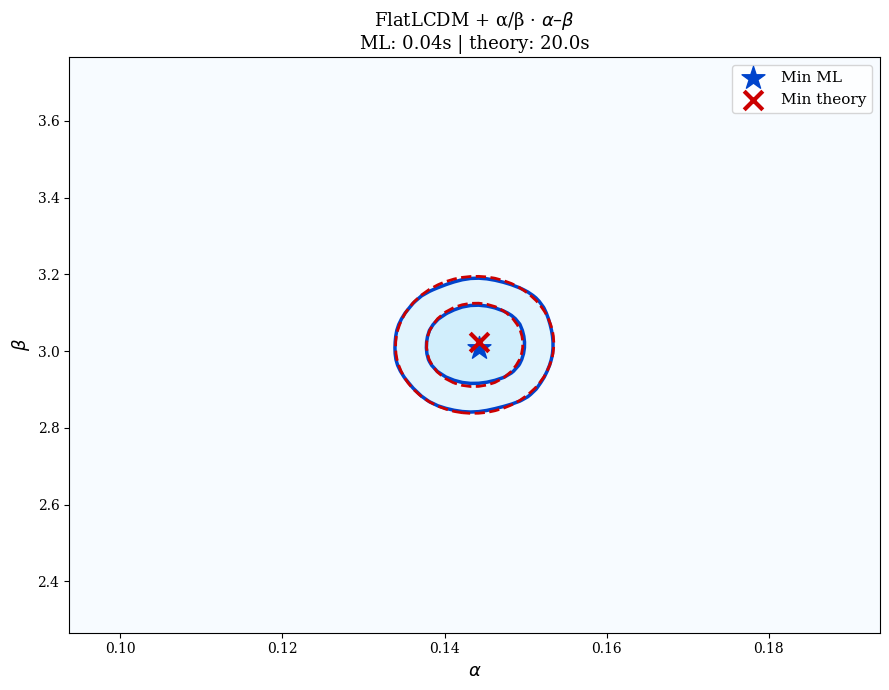

In [42]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.08, REF['Om']+0.08),
    H0=(REF['H0']-2.0, REF['H0']+2.0),
    alpha=(REF['alpha']-0.05, REF['alpha']+0.05),
    beta=(REF['beta']-0.75, REF['beta']+0.75),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", alpha=r"$\alpha$", beta=r"$\beta$")

# 6 contours of the 4D corner
for x, y in [('Om','H0'), ('Om','alpha'), ('Om','beta'),
             ('H0','alpha'), ('H0','beta'), ('alpha','beta')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"FlatLCDM + α/β · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_beeswarm.png


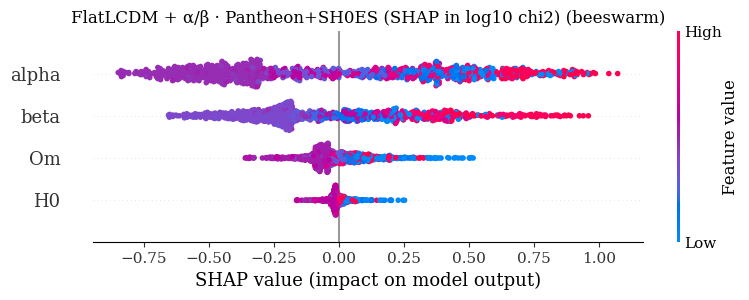

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_bar.png


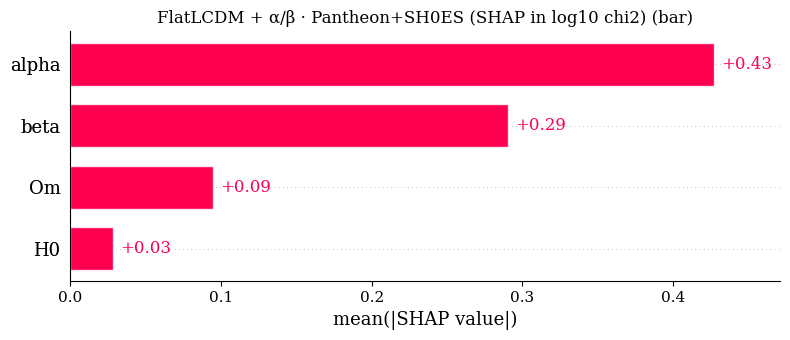

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_waterfall.png


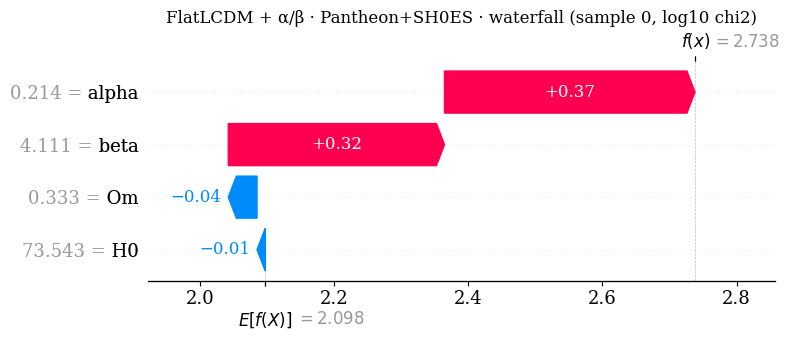

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_Om.png


<Figure size 640x480 with 0 Axes>

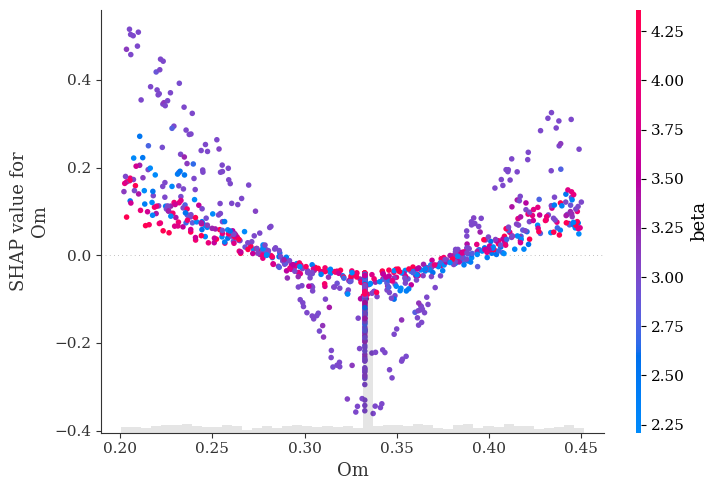

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_H0.png


<Figure size 640x480 with 0 Axes>

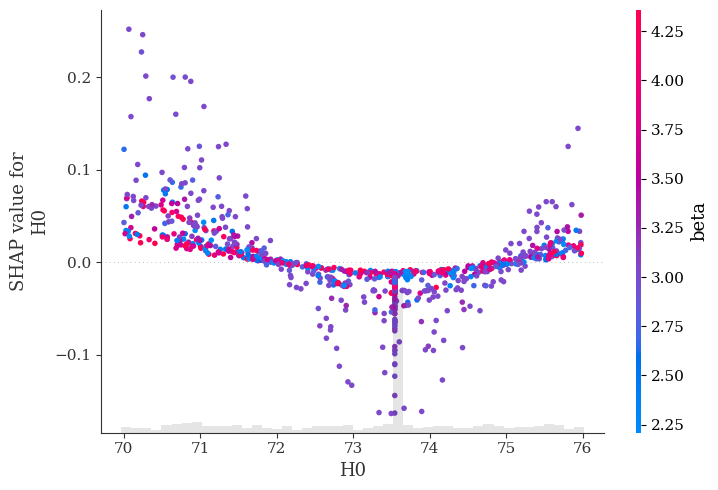

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_alpha.png


<Figure size 640x480 with 0 Axes>

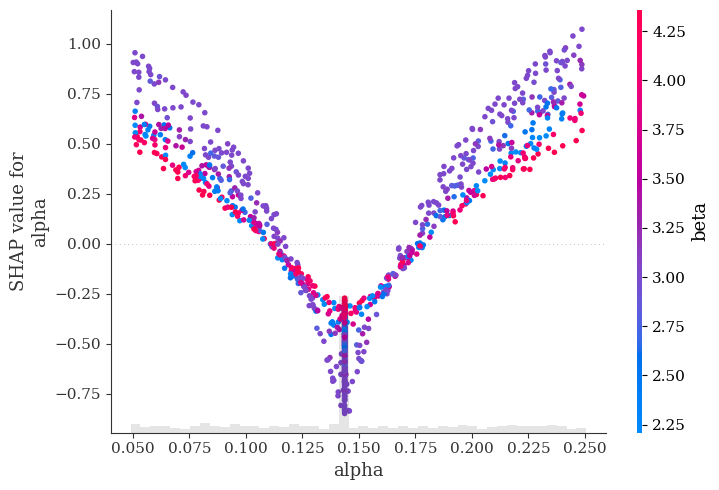

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_beta.png


<Figure size 640x480 with 0 Axes>

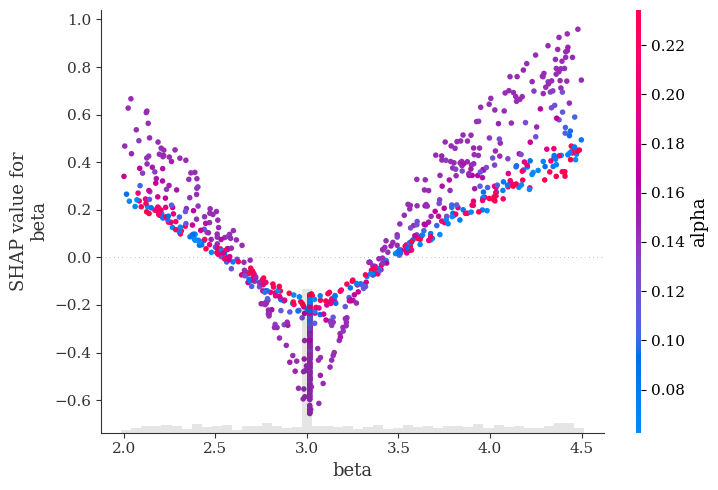

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_alpha.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_shap_beta.png')]

In [43]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="FlatLCDM + α/β · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="FlatLCDM + α/β · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)


--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=4) ---
  loading CPU booster copy...
  step   200/5000  |  86 it/s  |  ETA 56s  |  acc 0.31  |  diagonal
  step   400/5000  |  102 it/s  |  ETA 45s  |  acc 0.26  |  multivar
  step   600/5000  |  114 it/s  |  ETA ≤1s  |  acc 0.27  |  τ=33.7  ESS=3041/5000  |  multivar
  step   800/5000  |  119 it/s  |  ETA ≤0s  |  acc 0.28  |  τ=33.4  ESS=6131/5000  |  multivar
  done: 6.8s  |  119 it/s  |  acceptance 0.280  |  multivariate proposal
  flat chain: 205,312 samples (512 chains × 401 steps)  |  τ_max=33.4  |  ESS=6147
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_4_corner.png


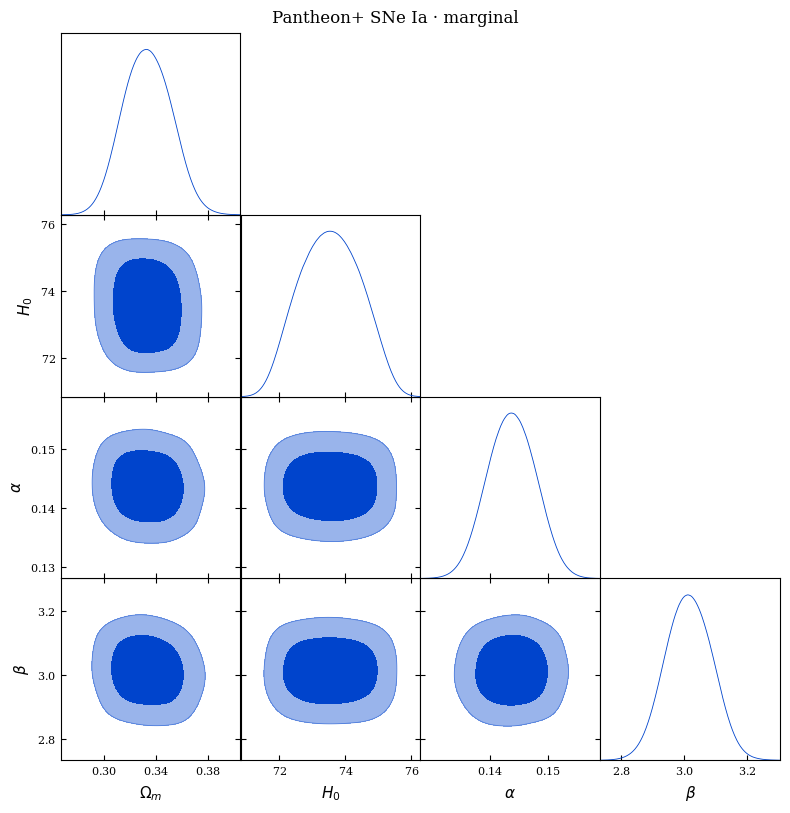

array([[ 0.29121161, 74.63433075,  0.14430138,  2.9648037 ],
       [ 0.30584788, 75.44845581,  0.13954017,  3.03696942],
       [ 0.3127144 , 75.17946625,  0.14246808,  2.82738256],
       ...,
       [ 0.33372122, 73.93517303,  0.14484942,  3.1958003 ],
       [ 0.33996633, 72.38986206,  0.13721393,  3.10618138],
       [ 0.38888359, 74.47784424,  0.14336556,  3.10664606]],
      shape=(205312, 4))

In [44]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="Pantheon+ SNe Ia · marginal",
    save_path=None,
    show=True,
)

## <a id="1-5"></a>1.5 wCDM — 3D (Om, H0, w) with Cepheids

**Model:** `FlatwCDM` (Om, H0, w); dark energy with constant equation of state.
**Data:** Pantheon+SH0ES with the standard mask.
**Cepheids:** **YES**.

First model with w free — LambdaCDM corresponds to w = -1.


In [45]:
SECTION = "1_5"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "w"]

sne = load_pantheon_plus(apply_mask=True)
print(f"Pantheon+ (masked): {len(sne)} SNe")

def chi2_fn(Om, H0, w):
    return chi2_sne(
        sne, model="FlatwCDM",
        Om=Om, H0=H0, w0=w,
        M="marginalize",
        use_cepheid_calibrators=True,
    )

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.334, 73.04, -1.0])))
_m.limits = [(0.1, 0.5), (65, 80), (-1.8, -0.4)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  w={REF['w']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ (masked): 1657 SNe
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2965  H0=73.4374  w=-0.9119
chi2(best-fit) = 1451.69


In [46]:
def builder():
    N = 7_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(Om=(0.0, 0.6), w=(-1.8, -0.2), H0=REF['H0'], _n=N),
            dict(Om=(0.0, 0.6), H0=(60, 85),    w=REF['w'],   _n=N),
            dict(H0=(60, 85),   w=(-1.8, -0.2), Om=REF['Om'], _n=N),
        ],
        random_box=dict(Om=(0.0, 0.65), H0=(55, 90), w=(-2.2, -0.1)),
        n_random=20_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_5_dataset.csv
min chi2 = 1451.718


  loading cached model: 1_5_model.ubj
  R2=0.99892 | best_iter=852 | n_train=34,850 | n_val=6,150
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_learning_curve.png


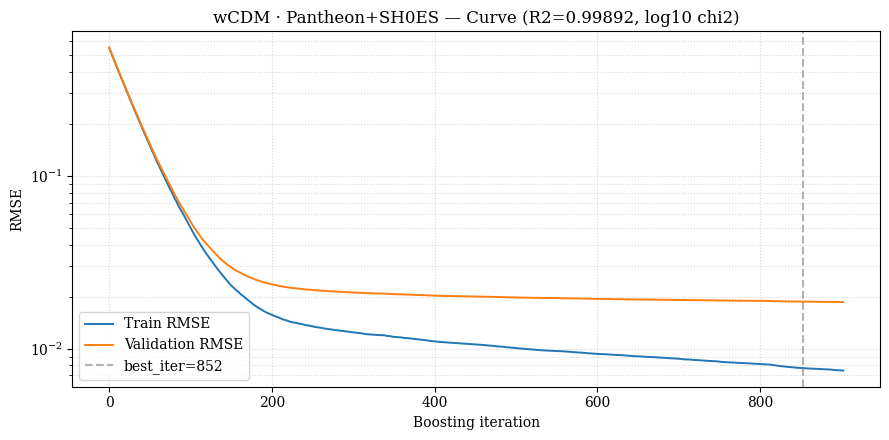

In [47]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"wCDM · Pantheon+SH0ES — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'w': -0.9118766319456396}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_Om_H0.png


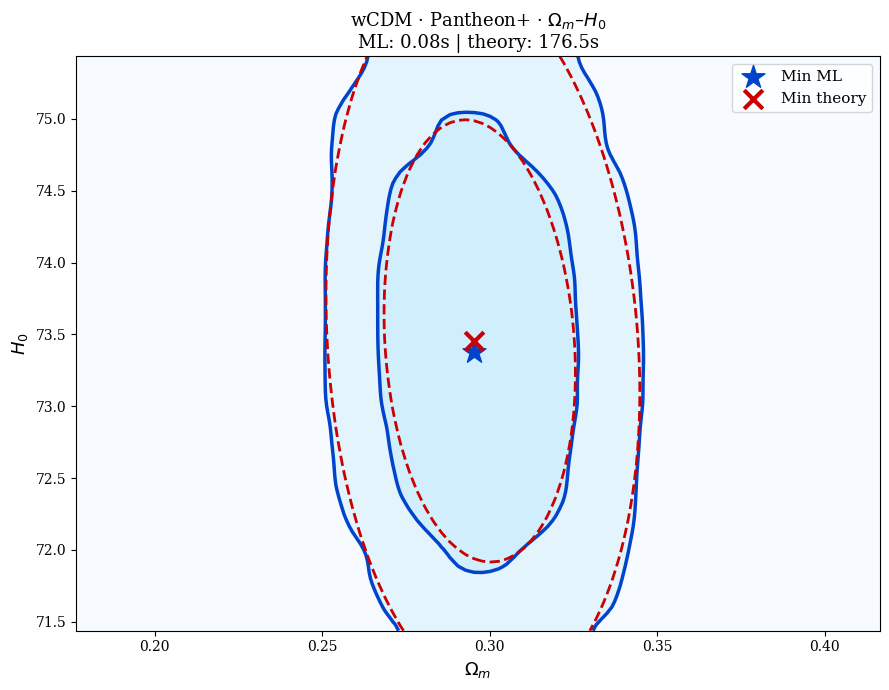

--- $w$ vs $\Omega_m$  ({'H0': 73.43742985304021}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_Om_w.png


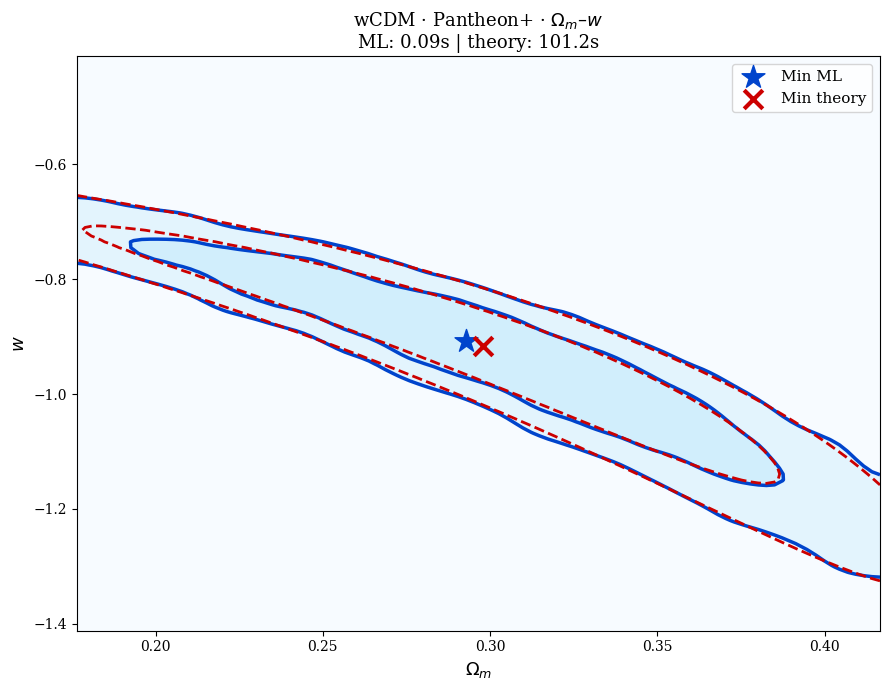

--- $w$ vs $H_0$  ({'Om': 0.2964935486244961}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_H0_w.png


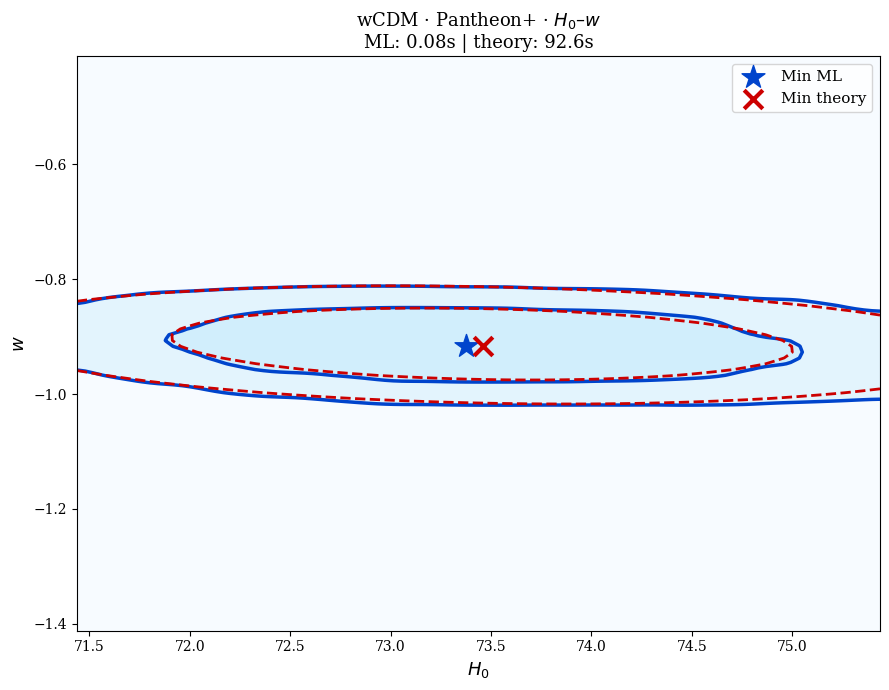

In [48]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.12, REF['Om']+0.12),
    H0=(REF['H0']-2.0, REF['H0']+2.0),
    w=(REF['w']-0.5, REF['w']+0.5),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", w=r"$w$")

for x, y in [('Om','H0'), ('Om','w'), ('H0','w')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"wCDM · Pantheon+ · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_beeswarm.png


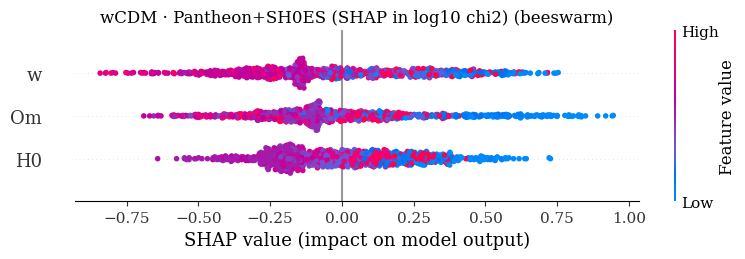

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_bar.png


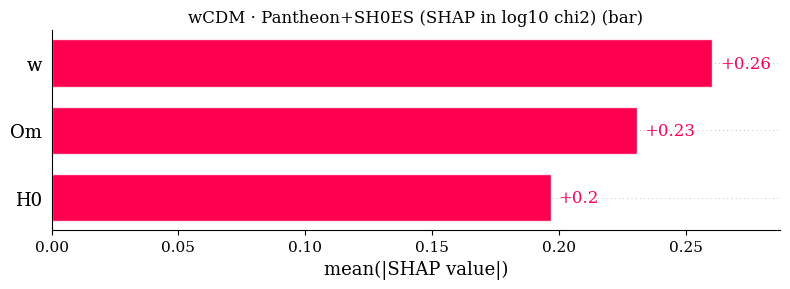

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_waterfall.png


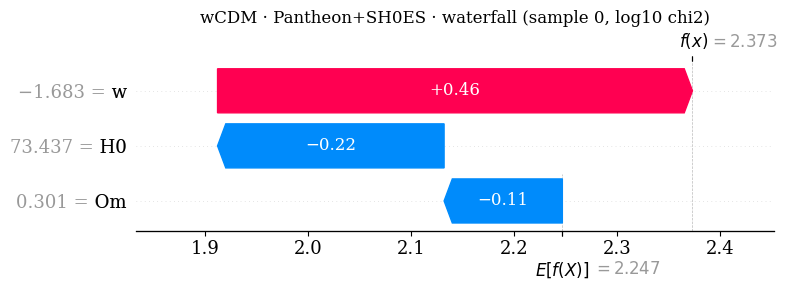

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_Om.png


<Figure size 640x480 with 0 Axes>

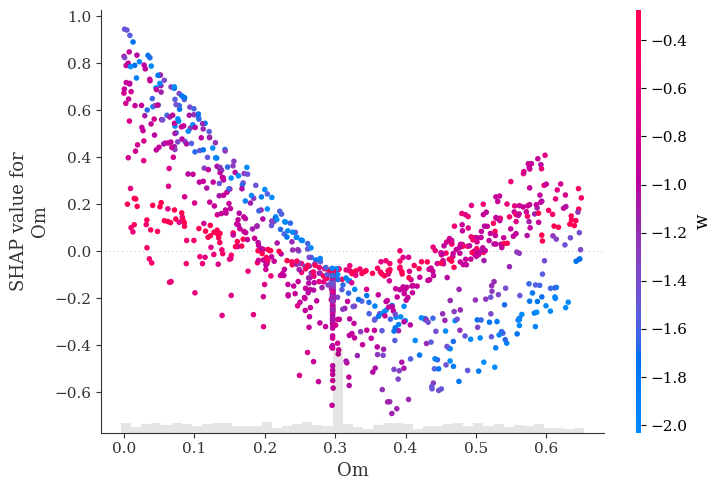

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_H0.png


<Figure size 640x480 with 0 Axes>

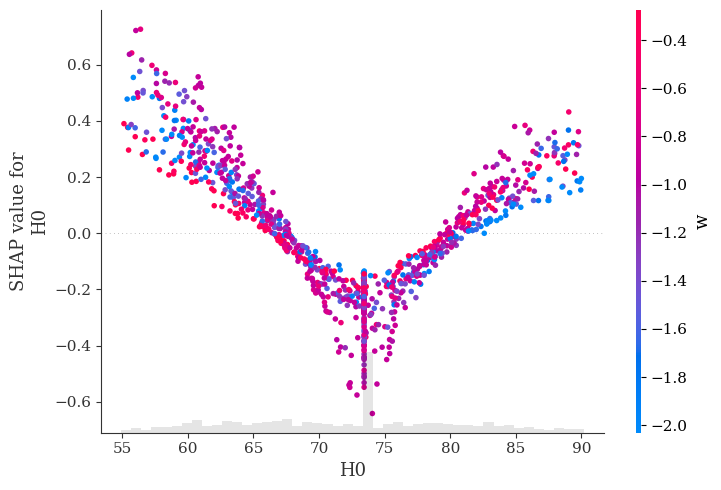

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_w.png


<Figure size 640x480 with 0 Axes>

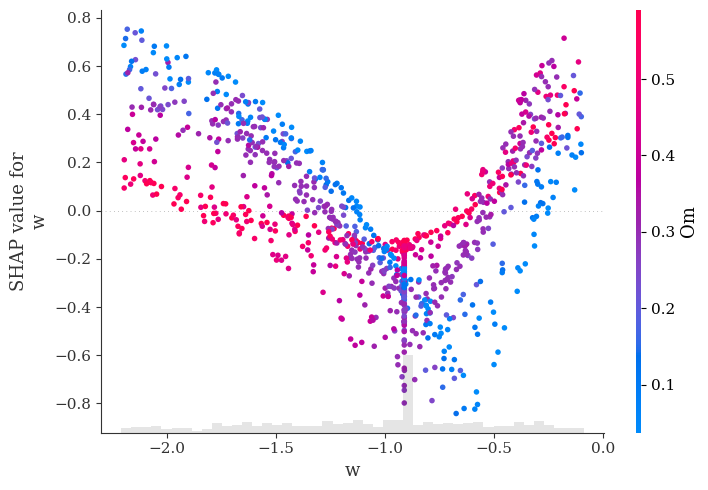

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_shap_w.png')]

In [49]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="wCDM · Pantheon+SH0ES (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="wCDM · Pantheon+SH0ES · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)


--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=3) ---
  loading CPU booster copy...
  step   200/5000  |  92 it/s  |  ETA 52s  |  acc 0.44  |  diagonal
  step   400/5000  |  97 it/s  |  ETA 47s  |  acc 0.36  |  multivar
  step   600/5000  |  100 it/s  |  ETA ≤1s  |  acc 0.34  |  τ=27.6  ESS=3710/5000  |  multivar
  step   800/5000  |  98 it/s  |  ETA ≤0s  |  acc 0.33  |  τ=34.9  ESS=5864/5000  |  multivar
  done: 8.2s  |  98 it/s  |  acceptance 0.333  |  multivariate proposal
  flat chain: 205,312 samples (512 chains × 401 steps)  |  τ_max=34.9  |  ESS=5878
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_5_corner.png


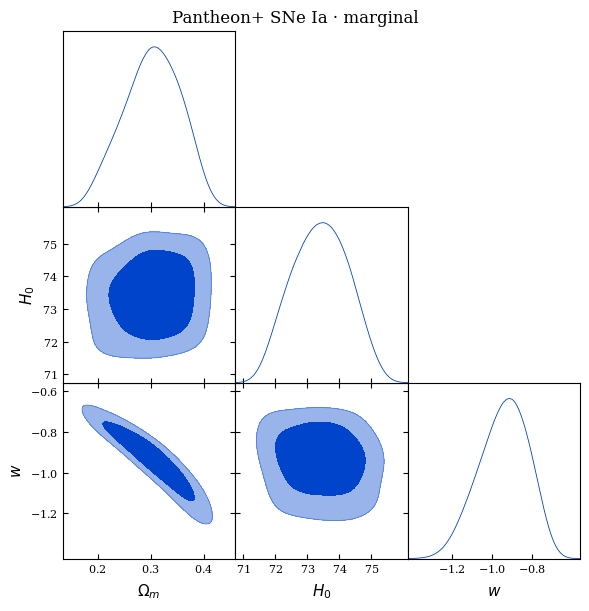

array([[ 0.2925868 , 73.39919281, -0.94155073],
       [ 0.32235134, 74.49068451, -0.92406726],
       [ 0.23732038, 73.49192047, -0.82634681],
       ...,
       [ 0.35338423, 71.89451599, -1.13130307],
       [ 0.35199496, 72.80001068, -1.04351127],
       [ 0.30509141, 72.9669342 , -0.92378992]], shape=(205312, 3))

In [50]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="Pantheon+ SNe Ia · marginal",
    save_path=None,
    show=True,
)

## <a id="1-6"></a>1.6 w0waCDM with SH0ES — 4D (Om, H0, w0, wa)

**Model:** `Flatw0waCDM` with the CPL parametrization w(z) = w0 + wa*z/(1+z).
**Data:** Pantheon+SH0ES with the standard mask.
**Cepheids:** **YES**.

First 4D scenario. wa characterizes the evolution of dark energy
(LambdaCDM corresponds to w0 = -1, wa = 0).


In [51]:
SECTION = "1_6"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "w0", "wa"]

sne = load_pantheon_plus(apply_mask=True)
print(f"Pantheon+ with SH0ES: {len(sne)} SNe, calibradores={sne.is_calib.sum()}")

def chi2_fn(Om, H0, w0, wa):
    return chi2_sne(
        sne, model="Flatw0waCDM",
        Om=Om, H0=H0, w0=w0, wa=wa,
        M="marginalize",
        use_cepheid_calibrators=True,
    )

# SN-only w0waCDM: wa is weakly constrained; REF.wa=0 (LCDM anchor)
import types
from iminuit import Minuit
print("Locating best-fit ...")
_m = Minuit(lambda Om, H0, w0, wa: chi2_fn(Om=Om, H0=H0, w0=w0, wa=wa), Om=0.3, H0=73.0, w0=-1.0, wa=0.0)
_m.limits = [(0.15, 0.45), (65, 80), (-2.0, 0.0), (-4,1)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), H0=float(_m.values['H0']), w0=float(_m.values['w0']), wa=float(_m.values['wa'])),
    x=[float(_m.values['Om']), float(_m.values['H0']), float(_m.values['w0']), float(_m.values['wa'])]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ with SH0ES: 1657 SNe, calibradores=77
Locating best-fit ...
Auto-detected best-fit:  Om=0.3074  H0=73.4258  w0=-0.9201  wa=-0.1102
chi2(best-fit) = 1451.69


In [52]:
def builder():
    N = 8_000
    pares = [("Om","H0"), ("Om","w0"), ("Om","wa"),
             ("H0","w0"), ("H0","wa"), ("w0","wa")]
    rangos = dict(Om=(0.0, 0.5), H0=(65, 80), w0=(-2.0, 0.2), wa=(-3.0, 2.0))
    slices = [{**REF, a: rangos[a], b: rangos[b], "_n": N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices,
        random_box=dict(Om=(0.2, 0.6), H0=(60, 85), w0=(-3, 0.2), wa=(-3, 2)),
        n_random=18_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_6_dataset.csv
min chi2 = 1451.691


  target in shifted-log10: range [0.000, 3.849]
  training: 22.63s | R2=0.99801 | best_iter=1307/3000  (early stop, ~56% saved)
  model cached: 1_6_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_learning_curve.png


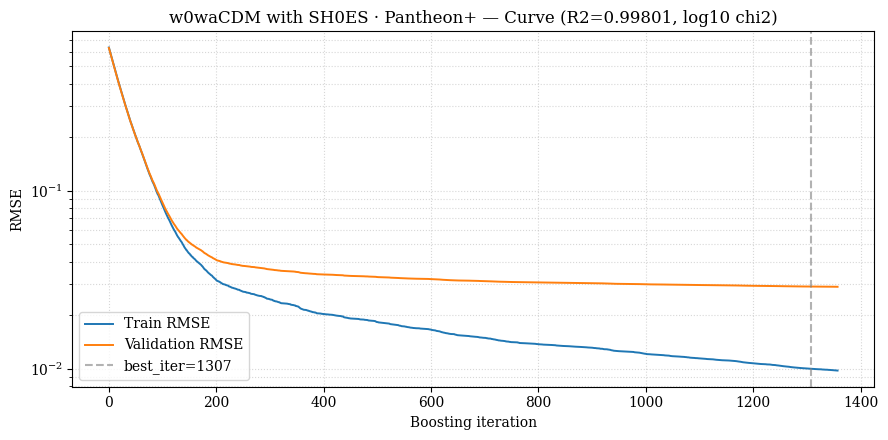

In [53]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=True,
)
plot_learning_curve(
    info,
    title=f"w0waCDM with SH0ES · Pantheon+ — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'w0': -0.9200984560380409, 'wa': -0.11021997128488922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_Om_H0.png


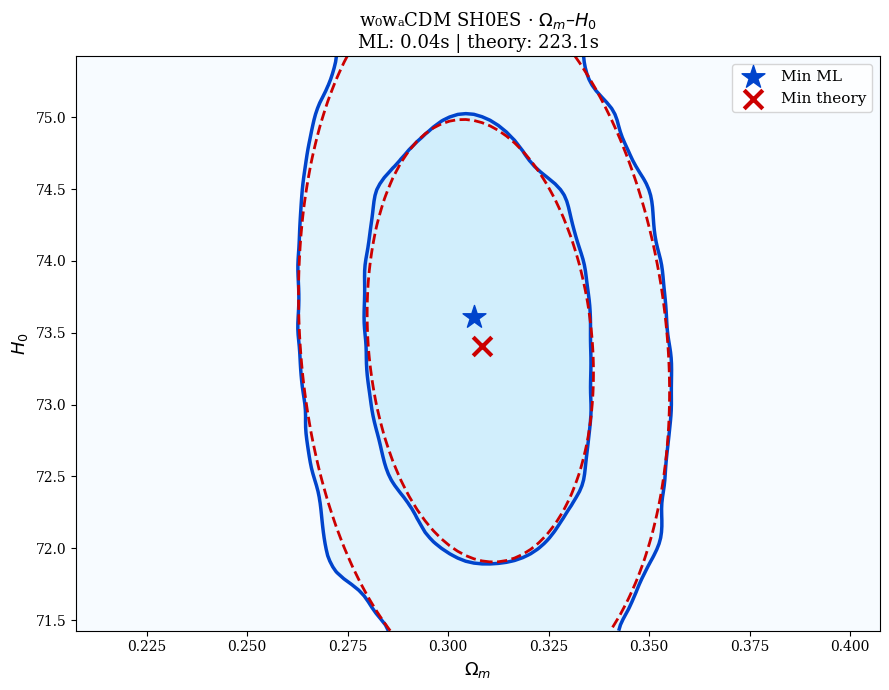

--- $w_0$ vs $\Omega_m$  ({'H0': 73.42578014942657, 'wa': -0.11021997128488922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_Om_w0.png


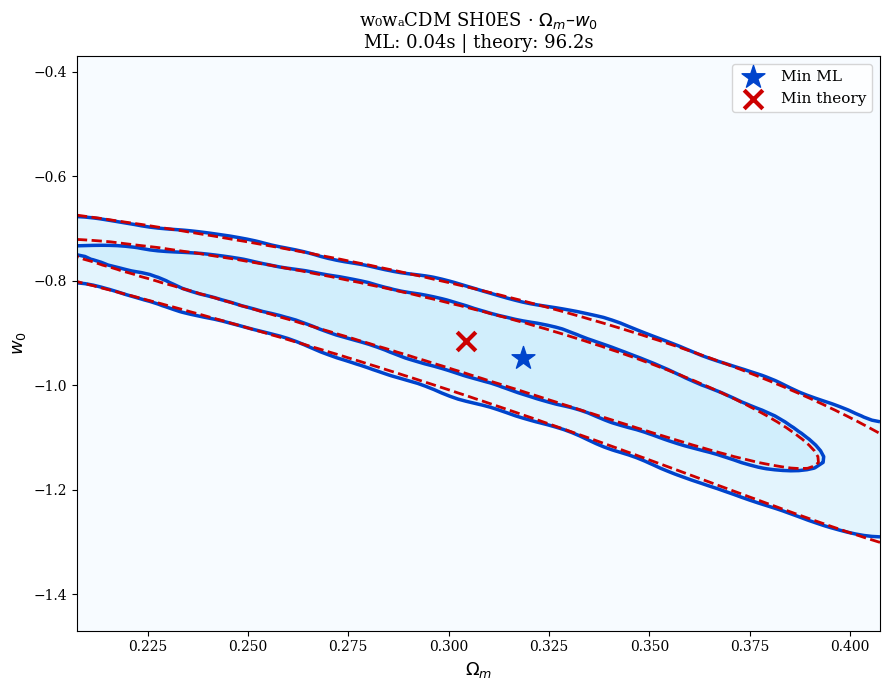

--- $w_a$ vs $\Omega_m$  ({'H0': 73.42578014942657, 'w0': -0.9200984560380409}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_Om_wa.png


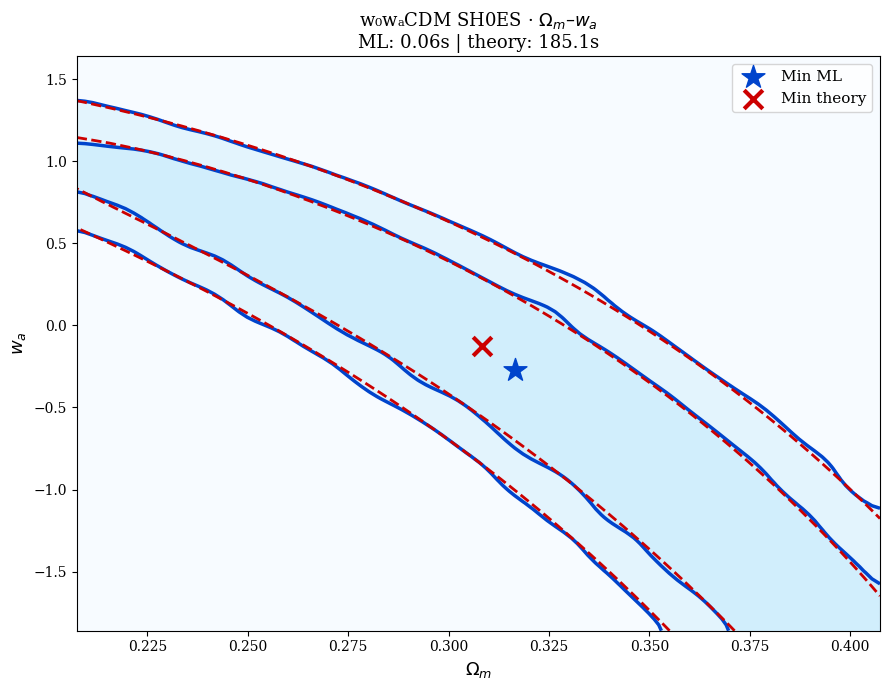

--- $w_0$ vs $H_0$  ({'Om': 0.3074145901926835, 'wa': -0.11021997128488922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_H0_w0.png


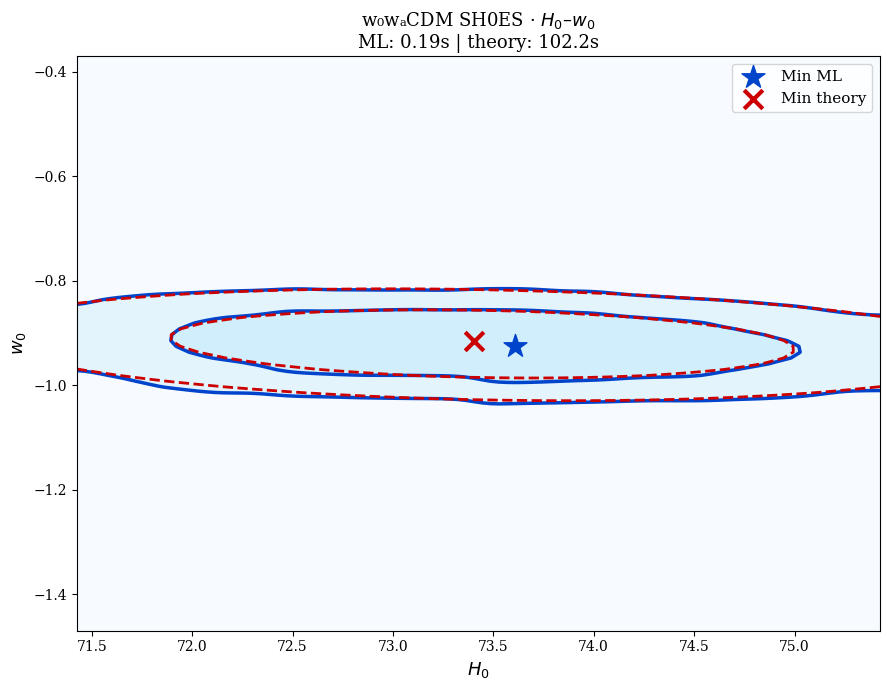

--- $w_a$ vs $H_0$  ({'Om': 0.3074145901926835, 'w0': -0.9200984560380409}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_H0_wa.png


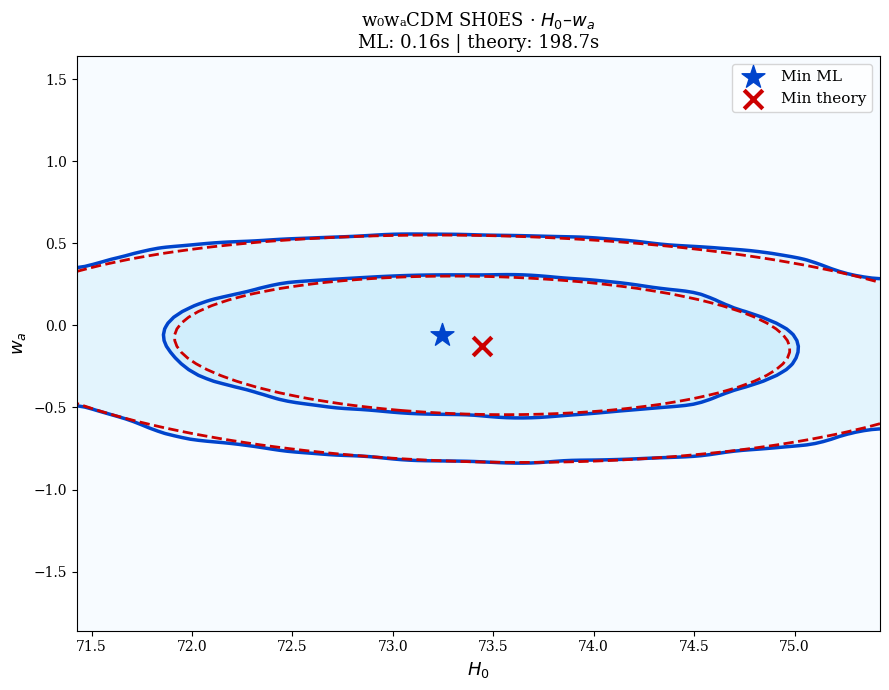

--- $w_a$ vs $w_0$  ({'Om': 0.3074145901926835, 'H0': 73.42578014942657}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_w0_wa.png


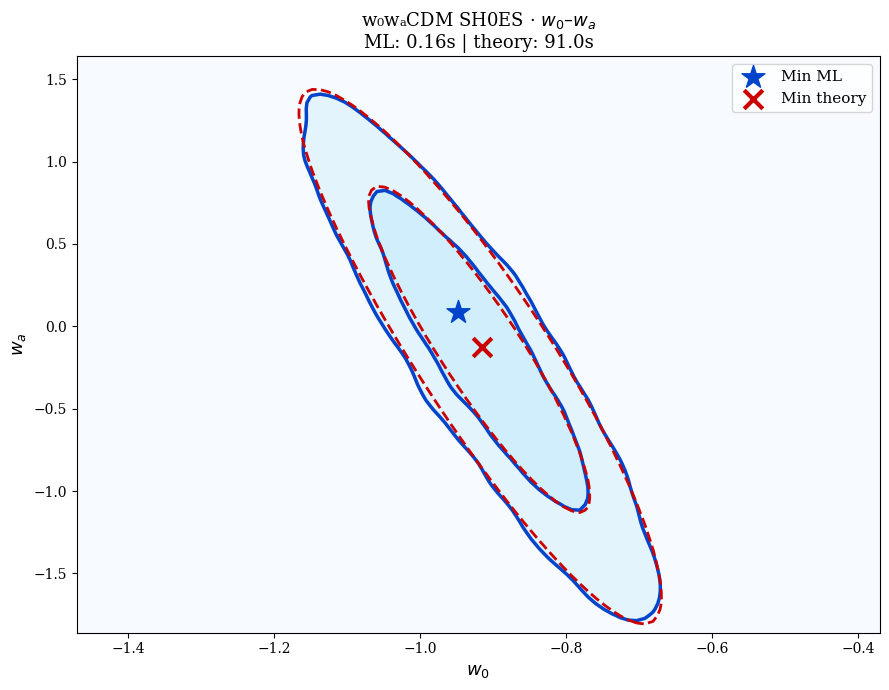

In [54]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.10, REF['Om']+0.10),
    H0=(REF['H0']-2.0, REF['H0']+2.0),
    w0=(REF['w0']-0.55, REF['w0']+0.55),
    wa=(REF['wa']-1.75, REF['wa']+1.75),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','H0'), ('Om','w0'), ('Om','wa'),
             ('H0','w0'), ('H0','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"w₀wₐCDM SH0ES · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_beeswarm.png


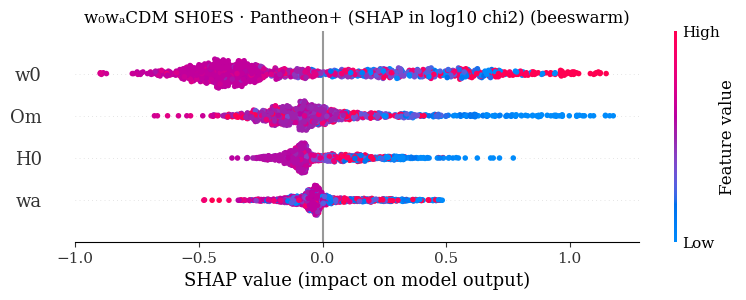

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_bar.png


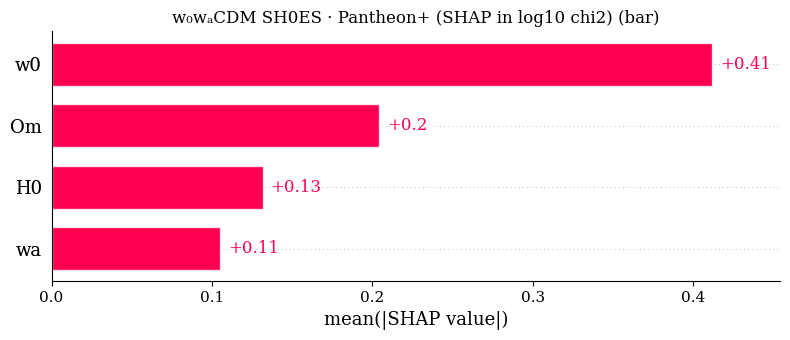

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_waterfall.png


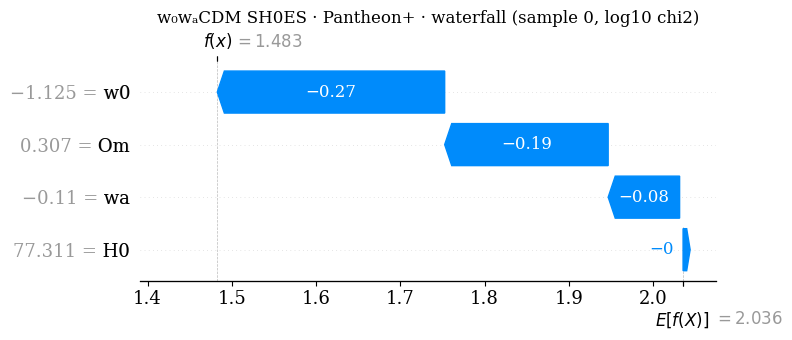

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_Om.png


<Figure size 640x480 with 0 Axes>

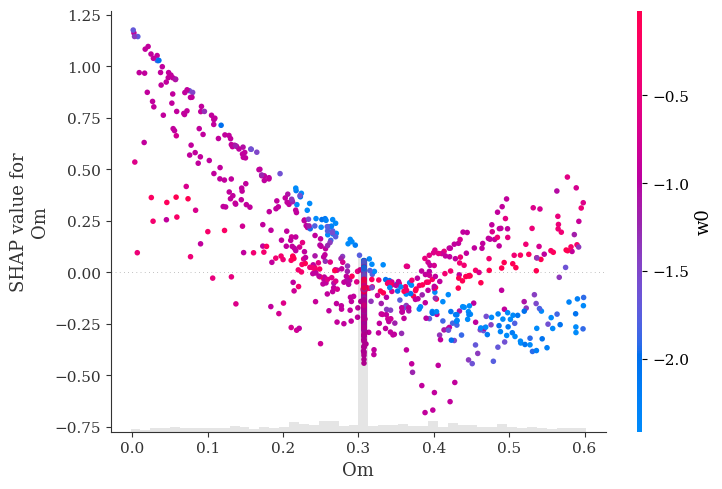

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_H0.png


<Figure size 640x480 with 0 Axes>

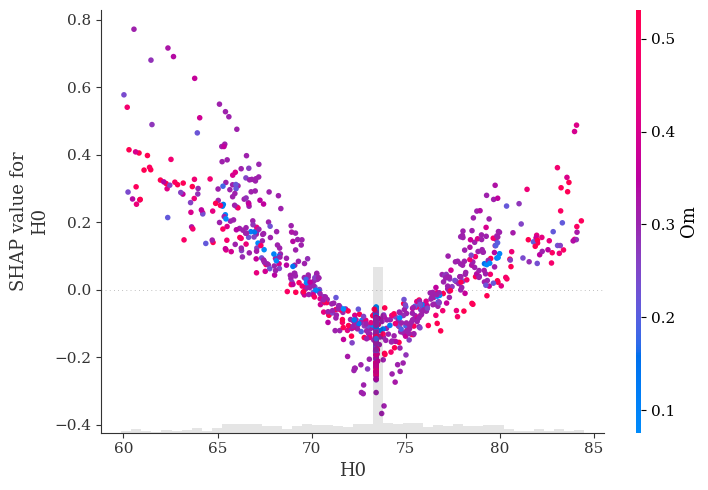

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_w0.png


<Figure size 640x480 with 0 Axes>

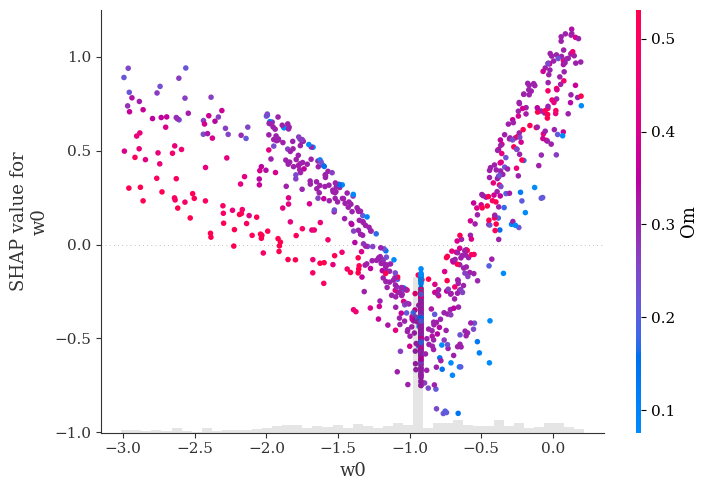

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_wa.png


<Figure size 640x480 with 0 Axes>

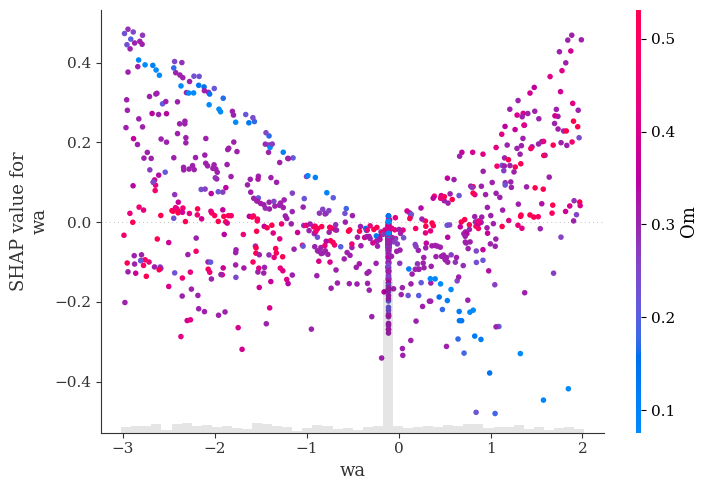

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_shap_wa.png')]

In [55]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="w₀wₐCDM SH0ES · Pantheon+ (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="w₀wₐCDM SH0ES · Pantheon+ · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)


--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=4) ---
  loading CPU booster copy...
  step   200/5000  |  30 it/s  |  ETA 163s  |  acc 0.39  |  diagonal
  step   400/5000  |  19 it/s  |  ETA 240s  |  acc 0.30  |  multivar
  step   600/5000  |  21 it/s  |  ETA ≤12s  |  acc 0.28  |  τ=45.0  ESS=2274/5000  |  multivar
  step   800/5000  |  24 it/s  |  ETA ≤6s  |  acc 0.27  |  τ=55.0  ESS=3721/5000  |  multivar
  step  1000/5000  |  24 it/s  |  ETA ≤3s  |  acc 0.26  |  τ=68.8  ESS=4466/5000  |  multivar
  step  1200/5000  |  25 it/s  |  ETA ≤0s  |  acc 0.25  |  τ=67.0  ESS=6116/5000  |  multivar
  done: 48.1s  |  25 it/s  |  acceptance 0.255  |  multivariate proposal
  flat chain: 410,112 samples (512 chains × 801 steps)  |  τ_max=67.0  |  ESS=6124
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_6_corner.png


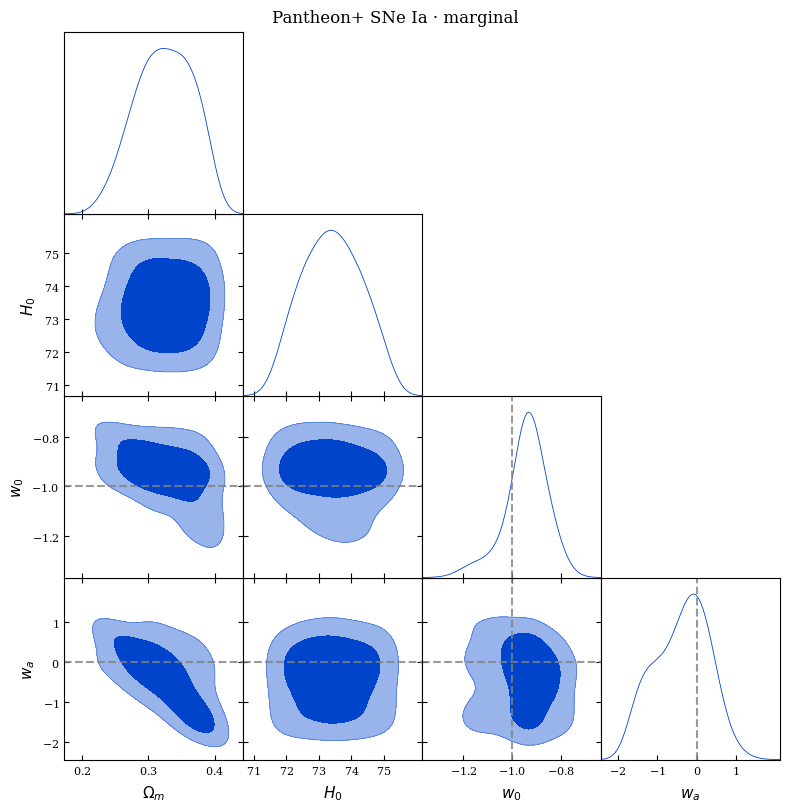

array([[ 2.43434504e-01,  7.30989456e+01, -8.28955650e-01,
        -4.19588208e-01],
       [ 3.04655164e-01,  7.45228424e+01, -9.10673559e-01,
         5.93310535e-01],
       [ 2.86667317e-01,  7.33411636e+01, -1.00254238e+00,
         3.53711605e-01],
       ...,
       [ 3.02807897e-01,  7.21421585e+01, -9.31507587e-01,
         2.03599036e-02],
       [ 3.64949048e-01,  7.22312698e+01, -1.01049805e+00,
        -1.45512843e+00],
       [ 3.09317946e-01,  7.37969818e+01, -9.81229782e-01,
         5.32076895e-01]], shape=(410112, 4))

In [56]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="Pantheon+ SNe Ia · marginal",
    save_path=None,
    show=True,
)

## <a id="1-7"></a>1.7 w0waCDM WITHOUT SH0ES — 4D (Om, H0, w0, wa)

**Model:** `Flatw0waCDM` (Om, H0, w0, wa) — same as 1.6.
**Data:** Pantheon+ with the z>0.01 mask but **without OR-ing the calibrators**.
**Cepheids:** **NO** (`use_cepheid_calibrators=False`, `keep_calibrators=False`).

Without the SH0ES anchor, H0 becomes poorly constrained.


In [63]:
SECTION = "1_7"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "w0", "wa"]

# No SH0ES: apply mask z>0.01 without OR-ing with is_calib (drop Cepheids)
sne = load_pantheon_plus(apply_mask=True, keep_calibrators=False)
print(f"Pantheon+ without SH0ES: {len(sne)} SNe (calibrators excluded)")

def chi2_fn(Om, H0, w0, wa):
    return chi2_sne(
        sne, model="Flatw0waCDM",
        Om=Om, H0=H0, w0=w0, wa=wa,
        M="marginalize",
        use_cepheid_calibrators=False,
    )

# SN-only w0waCDM
import types
from iminuit import Minuit
print("Locating best-fit ...")
_m = Minuit(lambda Om, H0, w0, wa: chi2_fn(Om=Om, H0=H0, w0=w0, wa=wa), Om=0.3, H0=70.0, w0=-1.0, wa=0.0)
_m.limits = [(0.15, 0.5), (60, 85), (-2.0, 0.0), (-3.0, 2.0)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), H0=float(_m.values['H0']), w0=float(_m.values['w0']), wa=float(_m.values['wa'])),
    x=[float(_m.values['Om']), float(_m.values['H0']), float(_m.values['w0']), float(_m.values['wa'])]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ without SH0ES: 1590 SNe (calibrators excluded)
Locating best-fit ...
Auto-detected best-fit:  Om=0.2018  H0=69.7885  w0=-0.8215  wa=0.5030
chi2(best-fit) = 1402.40


In [64]:
def builder():
    N = 8_000
    pares = [("Om","H0"), ("Om","w0"), ("Om","wa"),
             ("H0","w0"), ("H0","wa"), ("w0","wa")]
    rangos = dict(Om=(0.0, 0.5), H0=(55, 88), w0=(-2.0, 0.2), wa=(-3.0, 2.0))
    slices = [{**REF, a: rangos[a], b: rangos[b], "_n": N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices,
        random_box=dict(Om=(0.2, 0.6), H0=(50, 100), w0=(-3, 0.2), wa=(-3, 2)),
        n_random=18_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_7_dataset.csv
min chi2 = 1402.397


  loading cached model: 1_7_model.ubj
  R2=0.99867 | best_iter=647 | n_train=56,100 | n_val=9,900
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_learning_curve.png


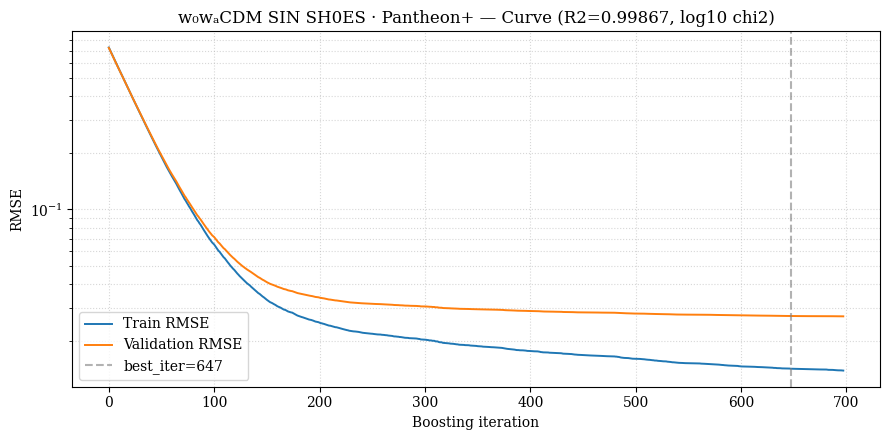

In [65]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"w₀wₐCDM SIN SH0ES · Pantheon+ — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'w0': -0.821500607927967, 'wa': 0.5029998004343564}) ---
  computing theory (parallel)...


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_Om_H0.png


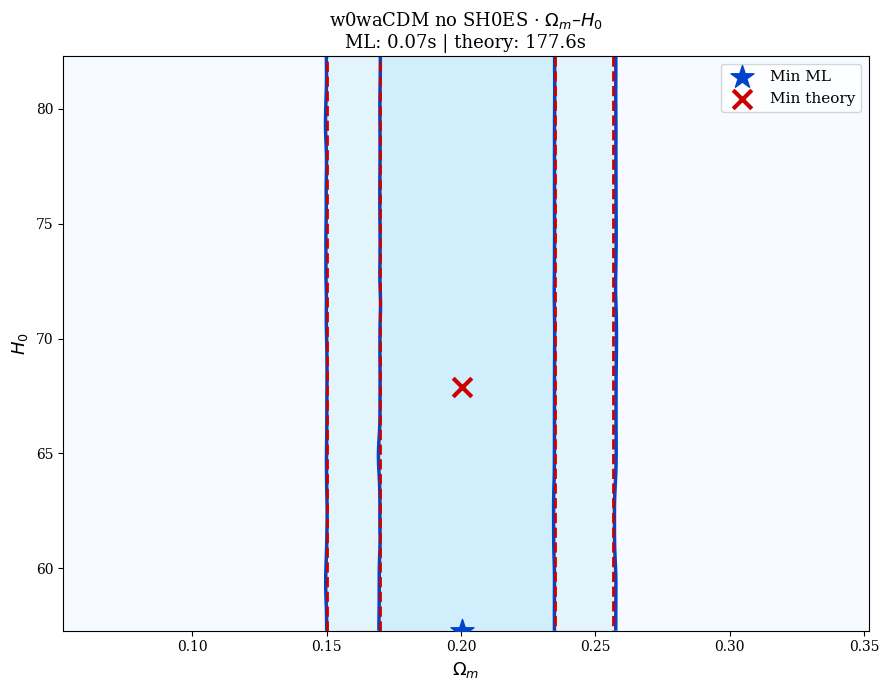

--- $w_0$ vs $\Omega_m$  ({'H0': 69.78852051040633, 'wa': 0.5029998004343564}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_Om_w0.png


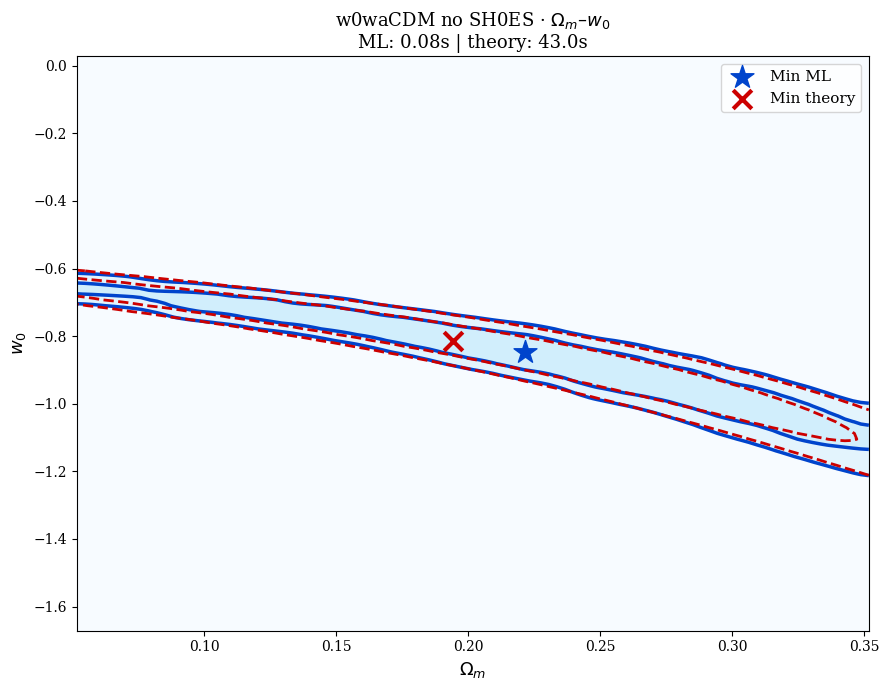

--- $w_a$ vs $\Omega_m$  ({'H0': 69.78852051040633, 'w0': -0.821500607927967}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_Om_wa.png


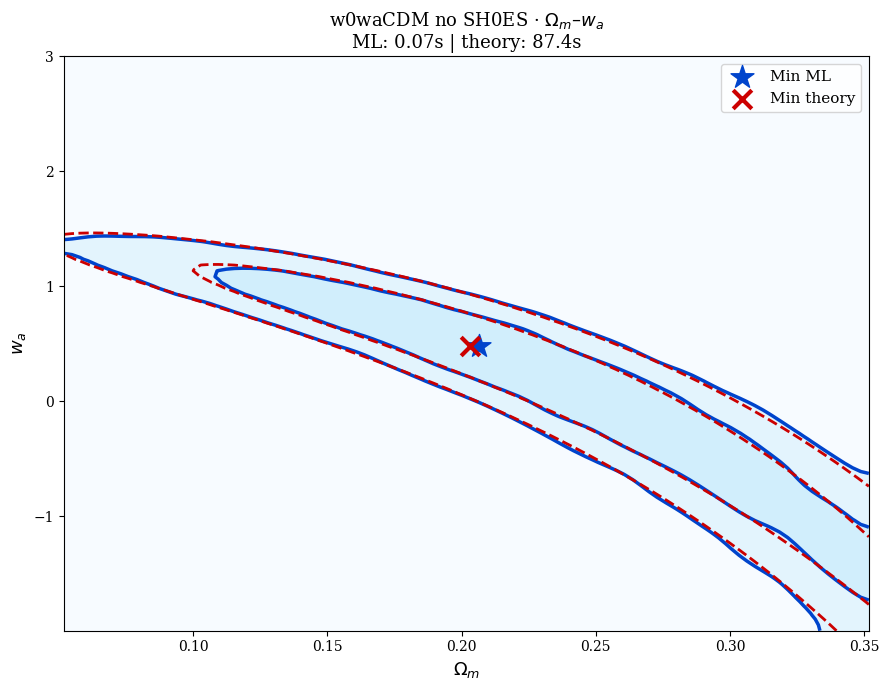

--- $w_0$ vs $H_0$  ({'Om': 0.2017650664730282, 'wa': 0.5029998004343564}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_H0_w0.png


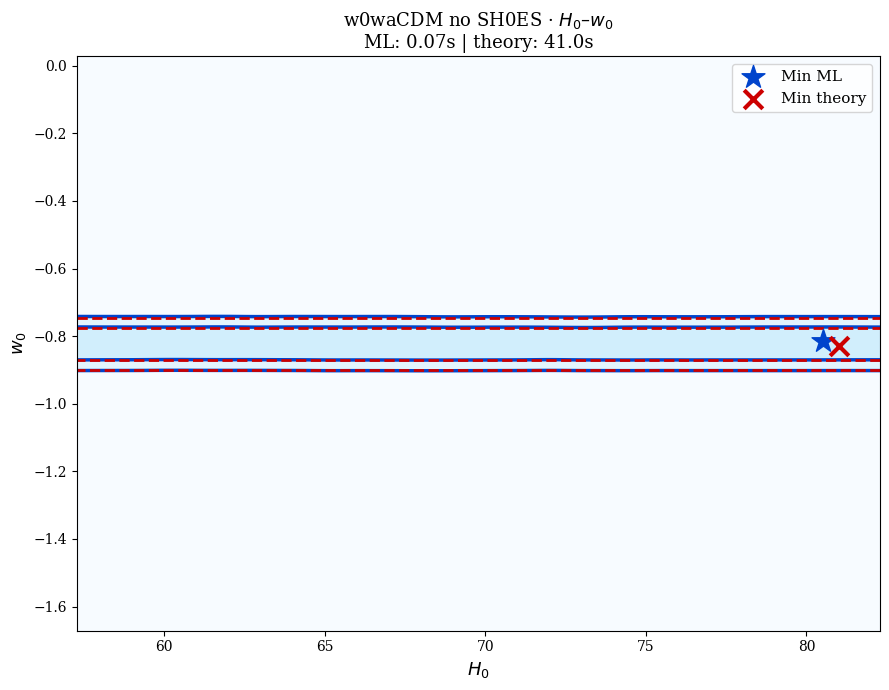

--- $w_a$ vs $H_0$  ({'Om': 0.2017650664730282, 'w0': -0.821500607927967}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_H0_wa.png


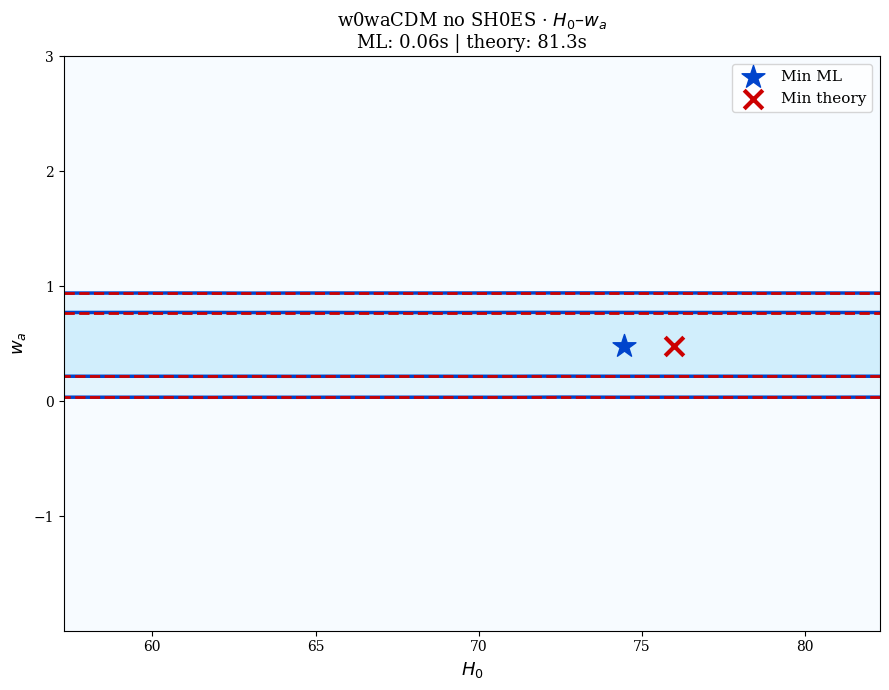

--- $w_a$ vs $w_0$  ({'Om': 0.2017650664730282, 'H0': 69.78852051040633}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_w0_wa.png


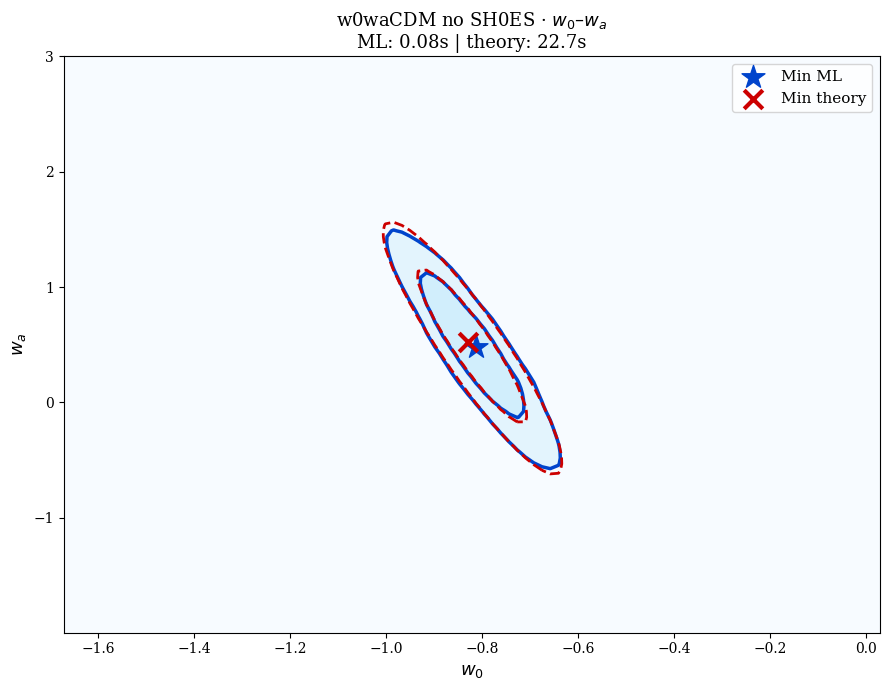

In [66]:
# Without SH0ES the H0 axis is very wide — H0 is nearly unconstrained.
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.15, REF['Om']+0.15),
    H0=(REF['H0']-12.5, REF['H0']+12.5),
    w0=(REF['w0']-0.85, REF['w0']+0.85),
    wa=(REF['wa']-2.5, REF['wa']+2.5),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','H0'), ('Om','w0'), ('Om','wa'),
             ('H0','w0'), ('H0','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"w0waCDM no SH0ES · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_beeswarm.png


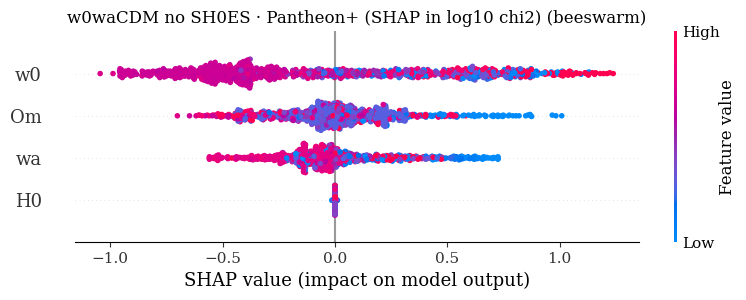

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_bar.png


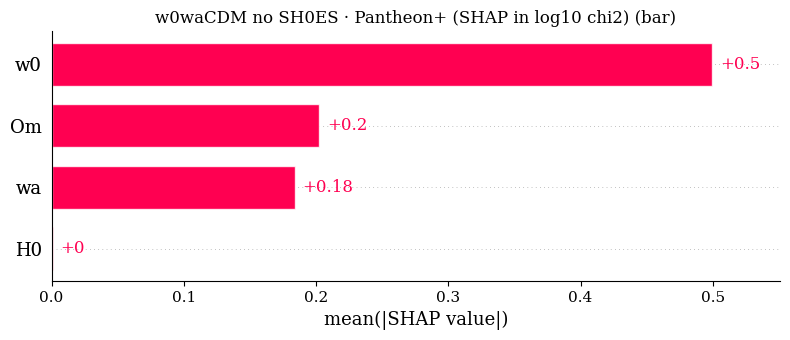

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_waterfall.png


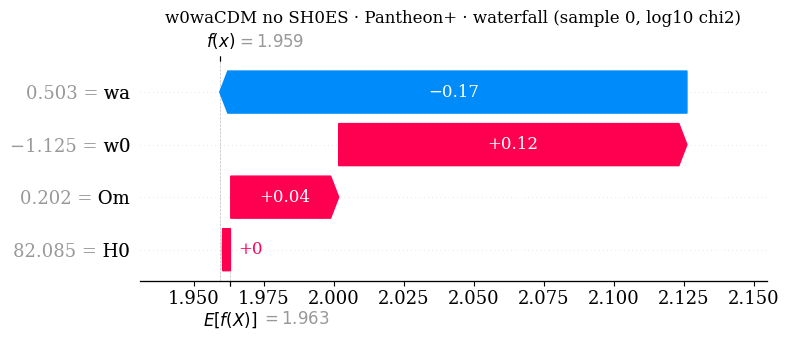

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_Om.png


<Figure size 640x480 with 0 Axes>

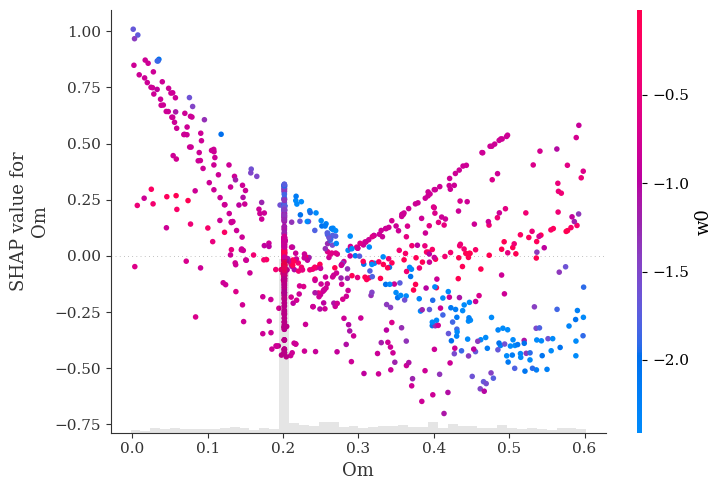

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_H0.png


<Figure size 640x480 with 0 Axes>

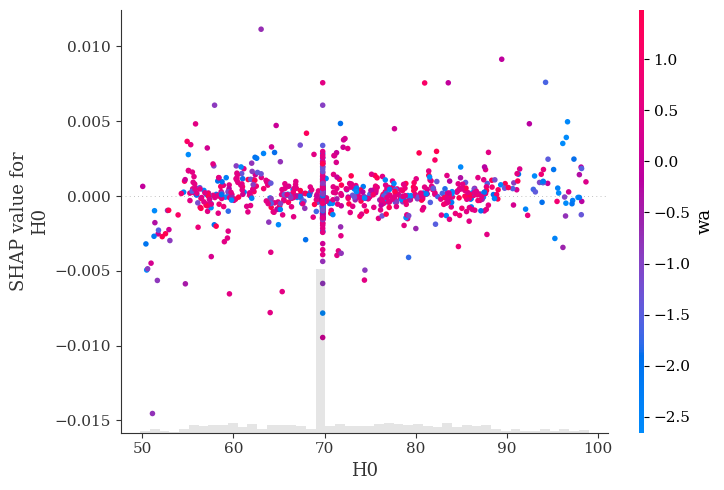

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_w0.png


<Figure size 640x480 with 0 Axes>

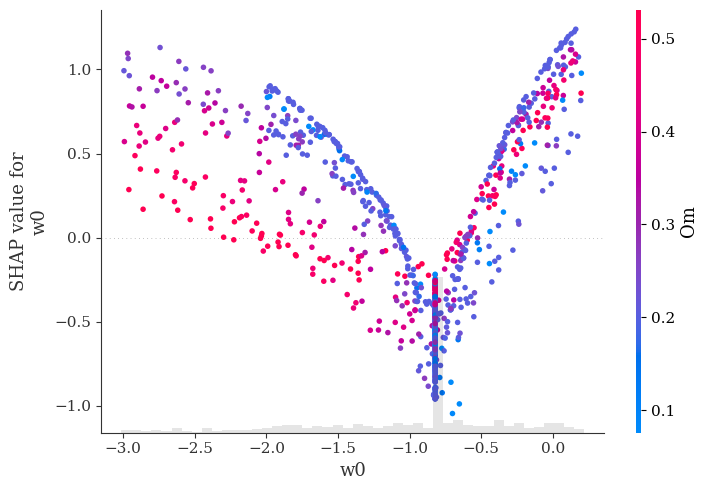

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_wa.png


<Figure size 640x480 with 0 Axes>

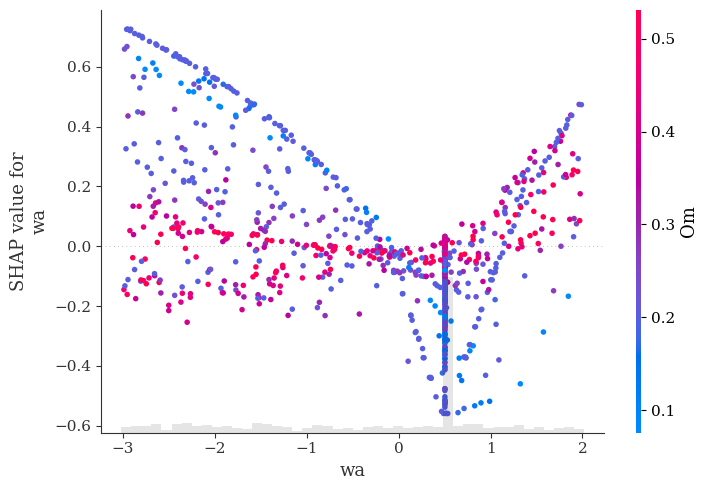

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_7_shap_wa.png')]

In [67]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="w0waCDM no SH0ES · Pantheon+ (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="w0waCDM no SH0ES · Pantheon+ · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)


--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=4) ---
  loading CPU booster copy...
  step   200/5000  |  107 it/s  |  ETA 45s  |  acc 0.38  |  diagonal
  step   400/5000  |  107 it/s  |  ETA 43s  |  acc 0.37  |  multivar
  step   600/5000  |  110 it/s  |  ETA ≤2s  |  acc 0.31  |  τ=48.2  ESS=2125/5000  |  multivar
  step   800/5000  |  113 it/s  |  ETA ≤5s  |  acc 0.27  |  τ=93.3  ESS=2194/5000  |  multivar
  step  1000/5000  |  113 it/s  |  ETA ≤7s  |  acc 0.25  |  τ=139.2  ESS=2207/5000  |  multivar
  step  1200/5000  |  110 it/s  |  ETA ≤9s  |  acc 0.24  |  τ=178.2  ESS=2299/5000  |  multivar
  step  1400/5000  |  109 it/s  |  ETA ≤2s  |  acc 0.23  |  τ=122.0  ESS=4195/5000  |  multivar
  step  1600/5000  |  108 it/s  |  ETA ≤0s  |  acc 0.23  |  τ=105.2  ESS=5842/5000  |  multivar
  done: 15.1s  |  106 it/s  |  acceptance 0.225  |  multivariate proposal
  flat chain: 614,912 samples (512 chains × 1201 steps)  |  τ_max=105.2  |  ESS=5847
Removed no burn in
  saved: 

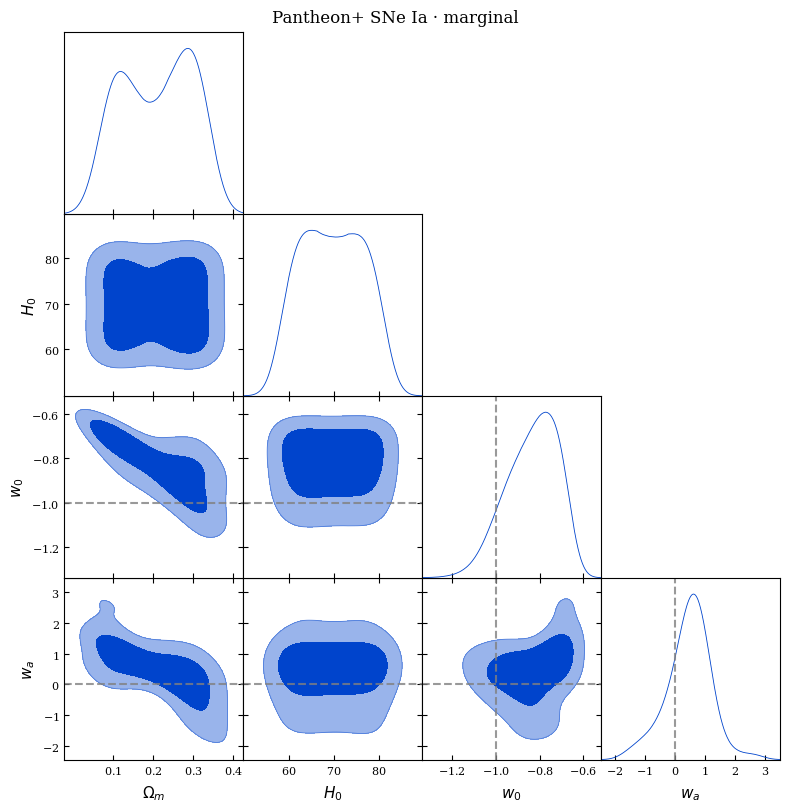

array([[ 0.22179687, 72.13290405, -0.82683122,  0.29411715],
       [ 0.09980366, 60.63201523, -0.72363359,  1.68669152],
       [ 0.09070203, 70.84751892, -0.68404055,  0.91326278],
       ...,
       [ 0.15230006, 74.83210754, -0.70559245,  0.19153608],
       [ 0.31328219, 78.79203796, -1.10344648,  0.83869648],
       [ 0.1197101 , 58.17136383, -0.74610925,  1.07774198]],
      shape=(614912, 4))

In [68]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="Pantheon+ SNe Ia · marginal",
    save_path=None,
    show=True,
)

## <a id="1-8"></a>1.8 w0waCDM with z>0.25 — 4D, no Cepheids, no local flow

**Model:** `Flatw0waCDM` (Om, H0, w0, wa).
**Data:** Pantheon+ with an aggressive z>0.25 cut (no Cepheids, no local flow).
**Cepheids:** **NO**.

Extreme test: only high-z SNe. H0 is almost completely unconstrained.


In [69]:
SECTION = "1_8"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "w0", "wa"]

# Aggressive z>0.25 cut, no calibrators
sne = load_pantheon_plus(apply_mask=True, z_min=0.25, keep_calibrators=False)
print(f"Pantheon+ z>0.25: {len(sne)} SNe (no Cepheids, no local flow)")

def chi2_fn(Om, H0, w0, wa):
    return chi2_sne(
        sne, model="Flatw0waCDM",
        Om=Om, H0=H0, w0=w0, wa=wa,
        M="marginalize",
        use_cepheid_calibrators=False,
    )

# SN-only w0waCDM: wa is weakly constrained; REF.wa=0 (LCDM anchor); se fija en 0 (referencia ΛCDM)
import types
from iminuit import Minuit
print("Locating best-fit (wa=0 fixed, SN-only)...")
_m = Minuit(lambda Om, H0, w0: chi2_fn(Om=Om, H0=H0, w0=w0, wa=0.0), Om=0.3, H0=70.0, w0=-1.0)
_m.limits = [(0.15, 0.5), (60, 85), (-2.0, 0.0)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), H0=float(_m.values['H0']), w0=float(_m.values['w0']), wa=0.0),
    x=[float(_m.values['Om']), float(_m.values['H0']), float(_m.values['w0']), 0.0]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Pantheon+ z>0.25: 614 SNe (no Cepheids, no local flow)
Locating best-fit (wa=0 fixed, SN-only)...
Auto-detected best-fit:  Om=0.1813  H0=72.6550  w0=-0.5799  wa=0.0000
chi2(best-fit) = 482.73


In [70]:
def builder():
    N = 8_000
    pares = [("Om","H0"), ("Om","w0"), ("Om","wa"),
             ("H0","w0"), ("H0","wa"), ("w0","wa")]
    rangos = dict(Om=(0.0, 0.5), H0=(55, 88), w0=(-2.0, 0.2), wa=(-3.0, 2.0))
    slices = [{**REF, a: rangos[a], b: rangos[b], "_n": N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices,
        random_box=dict(Om=(0.2, 0.6), H0=(50, 100), w0=(-3, 0.2), wa=(-3, 2)),
        n_random=18_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/1_8_dataset.csv
min chi2 = 482.525


  loading cached model: 1_8_model.ubj
  R2=0.99865 | best_iter=597 | n_train=56,100 | n_val=9,900
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_learning_curve.png


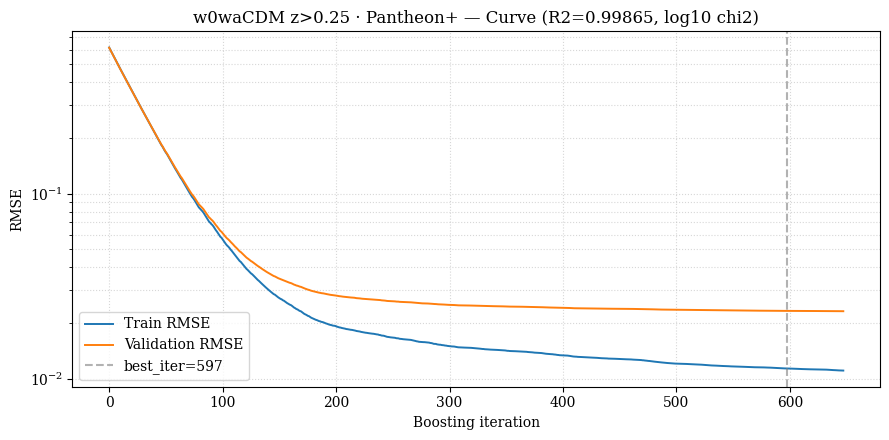

In [71]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"w0waCDM z>0.25 · Pantheon+ — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'w0': -0.579892120156617, 'wa': 0.0}) ---
  computing theory (parallel)...


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_Om_H0.png


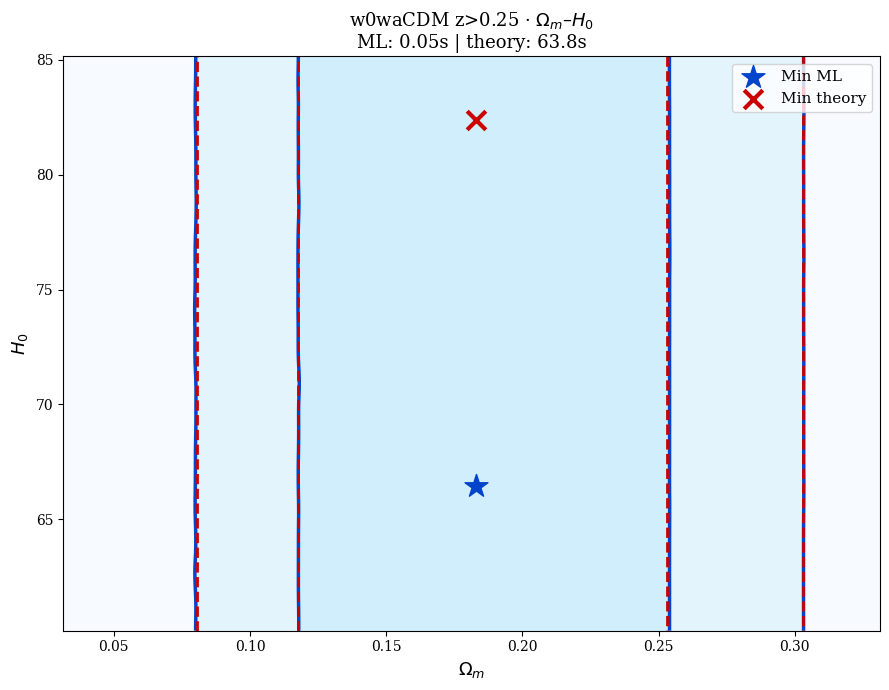

--- $w_0$ vs $\Omega_m$  ({'H0': 72.6550452209498, 'wa': 0.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_Om_w0.png


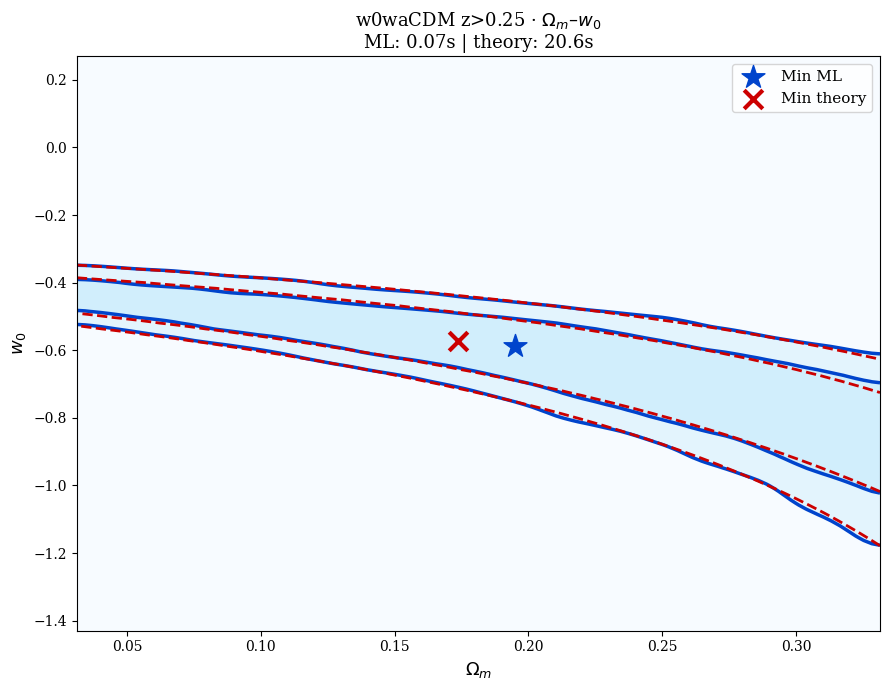

--- $w_a$ vs $\Omega_m$  ({'H0': 72.6550452209498, 'w0': -0.579892120156617}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_Om_wa.png


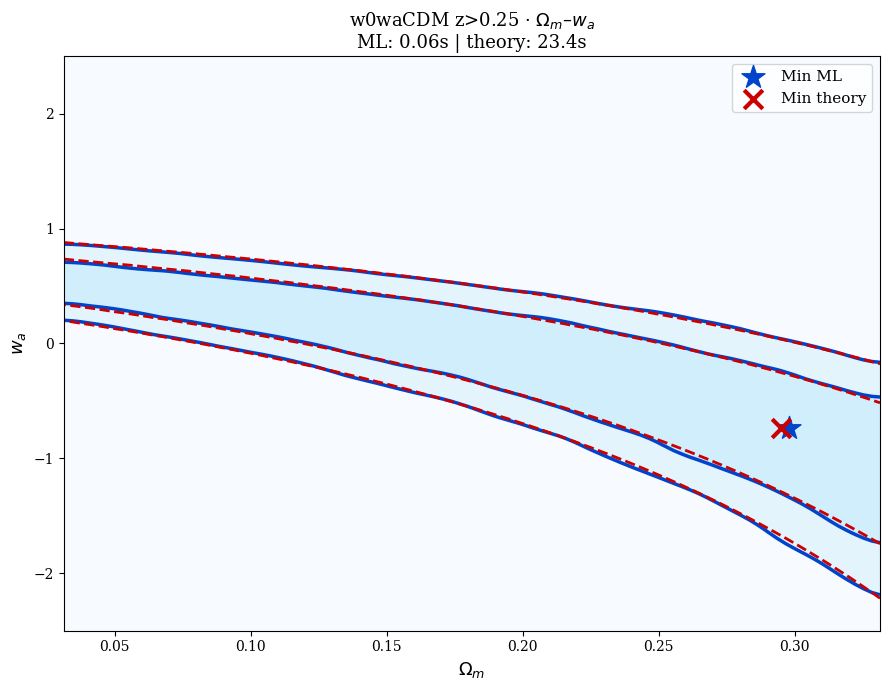

--- $w_0$ vs $H_0$  ({'Om': 0.18131066976248394, 'wa': 0.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_H0_w0.png


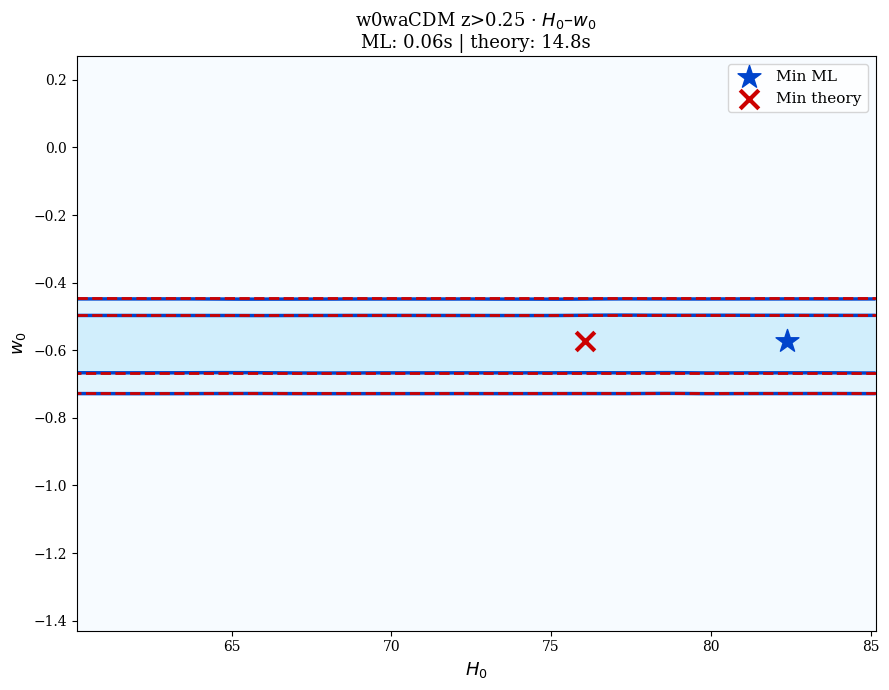

--- $w_a$ vs $H_0$  ({'Om': 0.18131066976248394, 'w0': -0.579892120156617}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_H0_wa.png


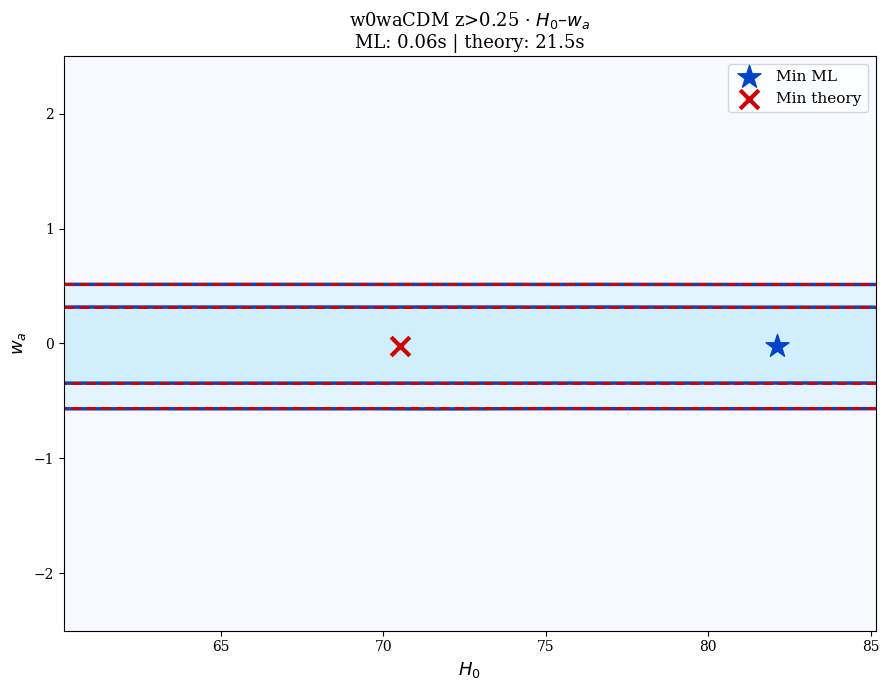

--- $w_a$ vs $w_0$  ({'Om': 0.18131066976248394, 'H0': 72.6550452209498}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_w0_wa.png


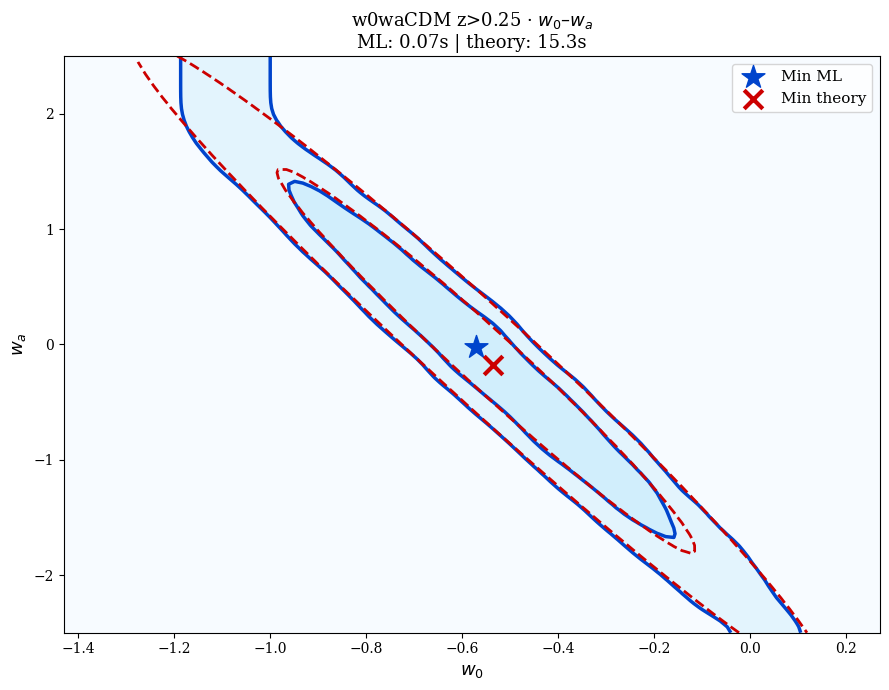

In [72]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.15, REF['Om']+0.15),
    H0=(REF['H0']-12.5, REF['H0']+12.5),
    w0=(REF['w0']-0.85, REF['w0']+0.85),
    wa=(REF['wa']-2.5, REF['wa']+2.5),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','H0'), ('Om','w0'), ('Om','wa'),
             ('H0','w0'), ('H0','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"w0waCDM z>0.25 · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_beeswarm.png


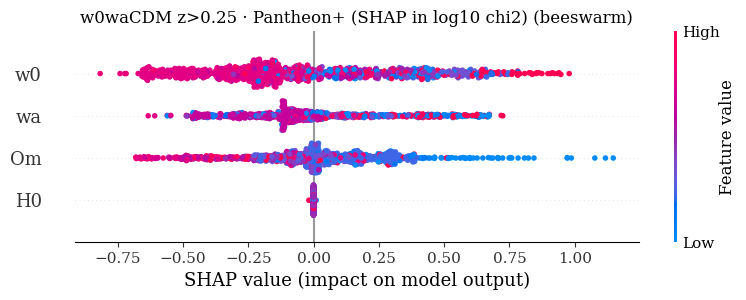

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_bar.png


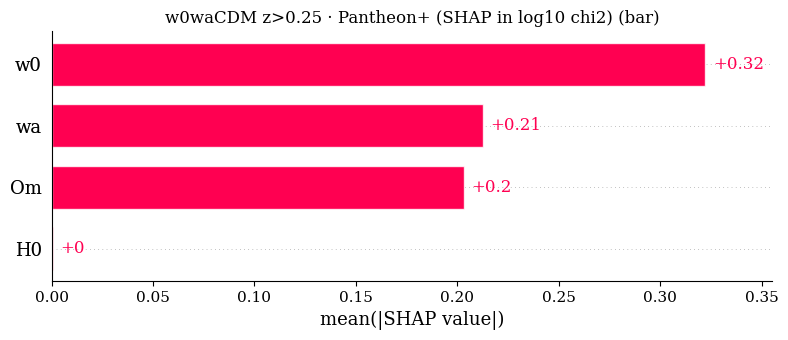

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_waterfall.png


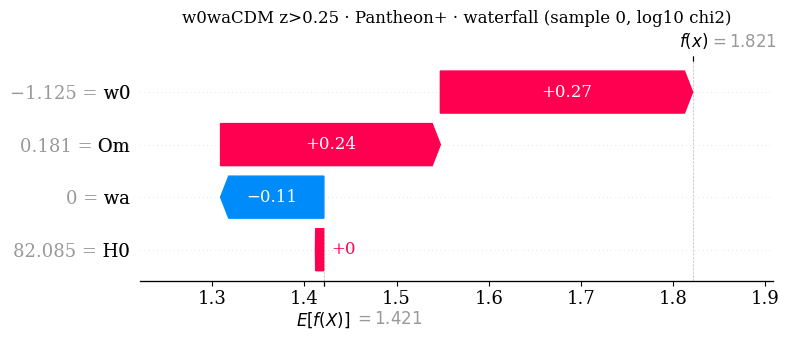

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_Om.png


<Figure size 640x480 with 0 Axes>

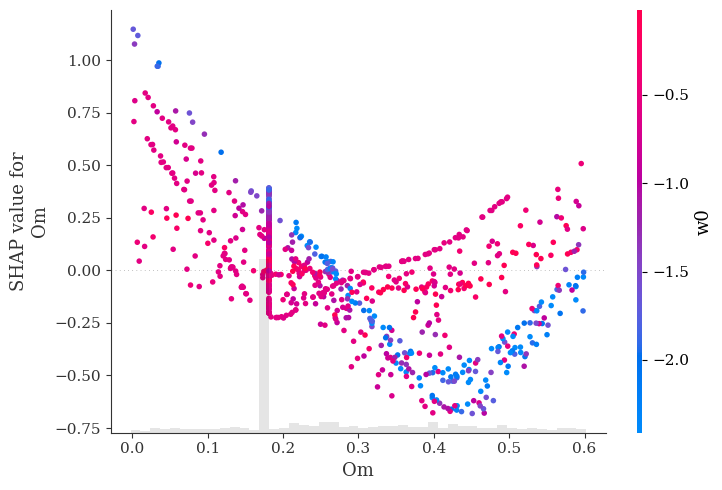

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_H0.png


<Figure size 640x480 with 0 Axes>

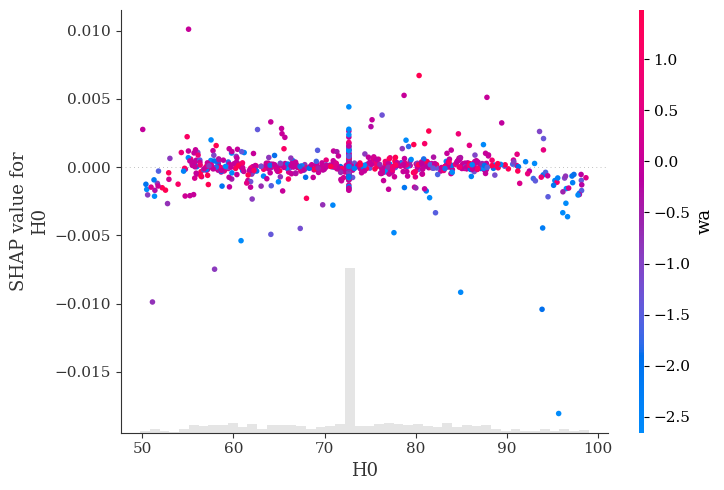

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_w0.png


<Figure size 640x480 with 0 Axes>

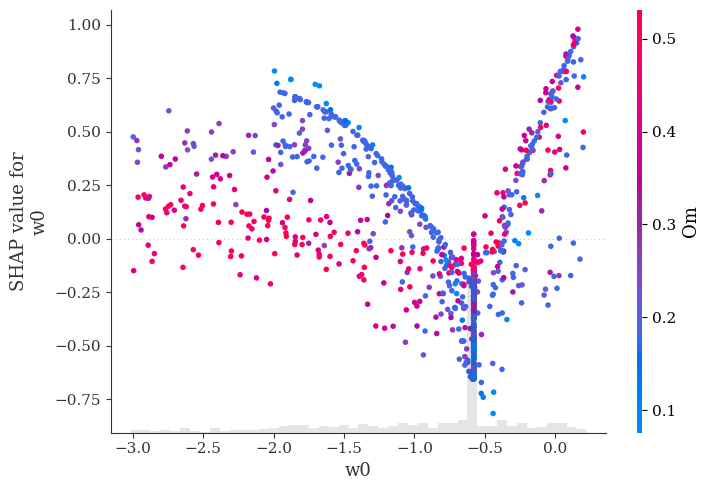

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_wa.png


<Figure size 640x480 with 0 Axes>

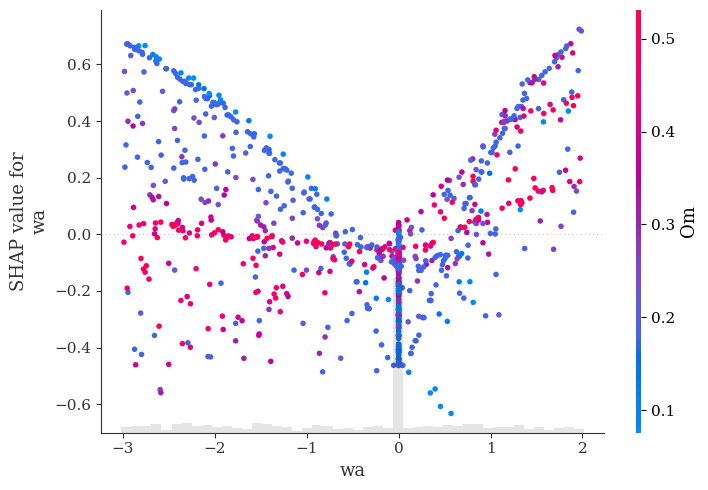

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_shap_wa.png')]

In [73]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="w0waCDM z>0.25 · Pantheon+ (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="w0waCDM z>0.25 · Pantheon+ · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)


--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=4) ---
  loading CPU booster copy...
  step   200/5000  |  128 it/s  |  ETA 38s  |  acc 0.36  |  diagonal
  step   400/5000  |  131 it/s  |  ETA 35s  |  acc 0.28  |  multivar
  step   600/5000  |  126 it/s  |  ETA ≤3s  |  acc 0.25  |  τ=53.7  ESS=1906/5000  |  multivar
  step   800/5000  |  128 it/s  |  ETA ≤2s  |  acc 0.24  |  τ=61.4  ESS=3337/5000  |  multivar
  step  1000/5000  |  127 it/s  |  ETA ≤1s  |  acc 0.23  |  τ=74.5  ESS=4123/5000  |  multivar
  step  1200/5000  |  128 it/s  |  ETA ≤0s  |  acc 0.23  |  τ=76.2  ESS=5379/5000  |  multivar
  done: 9.5s  |  127 it/s  |  acceptance 0.228  |  multivariate proposal
  flat chain: 410,112 samples (512 chains × 801 steps)  |  τ_max=76.2  |  ESS=5386
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/01_SN_Panth+/1_8_corner.png


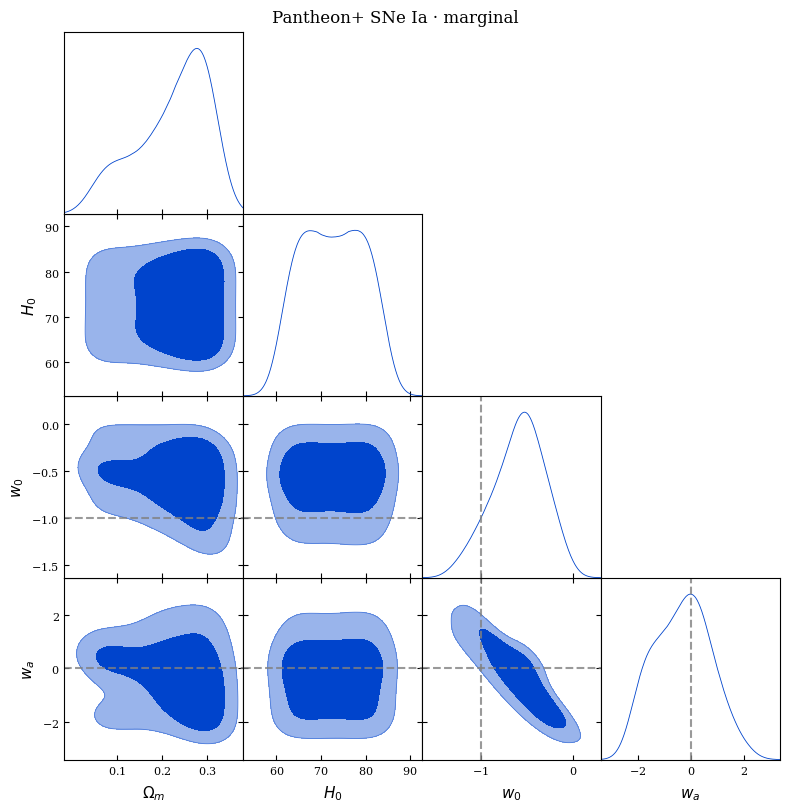

array([[ 0.28907147, 74.50219727, -0.42299587, -1.61945975],
       [ 0.30579877, 66.14070129, -0.75684118,  0.19788967],
       [ 0.28207761, 72.11403656, -0.34872669, -0.99235255],
       ...,
       [ 0.21149158, 68.92216492, -0.7499603 ,  0.69239557],
       [ 0.13847291, 62.03106689, -0.79003185,  0.71672231],
       [ 0.28129598, 72.40505219, -1.16007698,  1.48729646]],
      shape=(410112, 4))

In [74]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="Pantheon+ SNe Ia · marginal",
    save_path=None,
    show=True,
)